### Accident Severity Prediction

#### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam, AdamW

import optuna

#### Load Dataset

In [ ]:
# Read the dataset
US_acc_severe = pd.read_csv("../Accident-Severity Dataset/US_Accidents_March23.csv")

In [6]:
# Load the dataset - first 5 rows
US_acc_severe.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [7]:
# Load the dataset - last 5 rows
US_acc_severe.tail()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
7728389,A-7777757,Source1,2,2019-08-23 18:03:25,2019-08-23 18:32:01,34.00248,-117.37936,33.99888,-117.37094,0.543,...,False,False,False,False,False,False,Day,Day,Day,Day
7728390,A-7777758,Source1,2,2019-08-23 19:11:30,2019-08-23 19:38:23,32.76696,-117.14806,32.76555,-117.15363,0.338,...,False,False,False,False,False,False,Day,Day,Day,Day
7728391,A-7777759,Source1,2,2019-08-23 19:00:21,2019-08-23 19:28:49,33.77545,-117.84779,33.77740,-117.85727,0.561,...,False,False,False,False,False,False,Day,Day,Day,Day
7728392,A-7777760,Source1,2,2019-08-23 19:00:21,2019-08-23 19:29:42,33.99246,-118.40302,33.98311,-118.39565,0.772,...,False,False,False,False,False,False,Day,Day,Day,Day
7728393,A-7777761,Source1,2,2019-08-23 18:52:06,2019-08-23 19:21:31,34.13393,-117.23092,34.13736,-117.23934,0.537,...,False,False,False,False,False,False,Day,Day,Day,Day


#### Analysing the dataset

In [8]:
# Observe the datasets size and structure
US_acc_severe.shape

(7728394, 46)

In [9]:
US_acc_severe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

In [10]:
US_acc_severe.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [11]:
# Understanding the datasets statistics
US_acc_severe.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,3.346207e+01,-1.177543e+02,0.000000e+00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


#### Data Cleaning

In [12]:
# Checking for missing values
US_acc_severe.isnull().sum().sort_values(ascending=False)

,0
End_Lng,3402762
End_Lat,3402762
Precipitation(in),2203586
Wind_Chill(F),1999019
Wind_Speed(mph),571233
Visibility(mi),177098
Wind_Direction,175206
Humidity(%),174144
Weather_Condition,173459
Temperature(F),163853


In [13]:
# The percentage of the top features with missing values
total_percent = US_acc_severe.isnull().sum().sort_values(ascending=False)
print(total_percent/len(US_acc_severe)*100)

End_Lng                  44.029355
End_Lat                  44.029355
Precipitation(in)        28.512858
Wind_Chill(F)            25.865904
Wind_Speed(mph)           7.391355
Visibility(mi)            2.291524
Wind_Direction            2.267043
Humidity(%)               2.253301
Weather_Condition         2.244438
Temperature(F)            2.120143
Pressure(in)              1.820288
Weather_Timestamp         1.555666
Sunrise_Sunset            0.300787
Civil_Twilight            0.300787
Astronomical_Twilight     0.300787
Nautical_Twilight         0.300787
Airport_Code              0.292881
Street                    0.140637
Timezone                  0.101030
Zipcode                   0.024779
City                      0.003274
Description               0.000065
ID                        0.000000
Distance(mi)              0.000000
Start_Lng                 0.000000
Source                    0.000000
Severity                  0.000000
Start_Time                0.000000
End_Time            

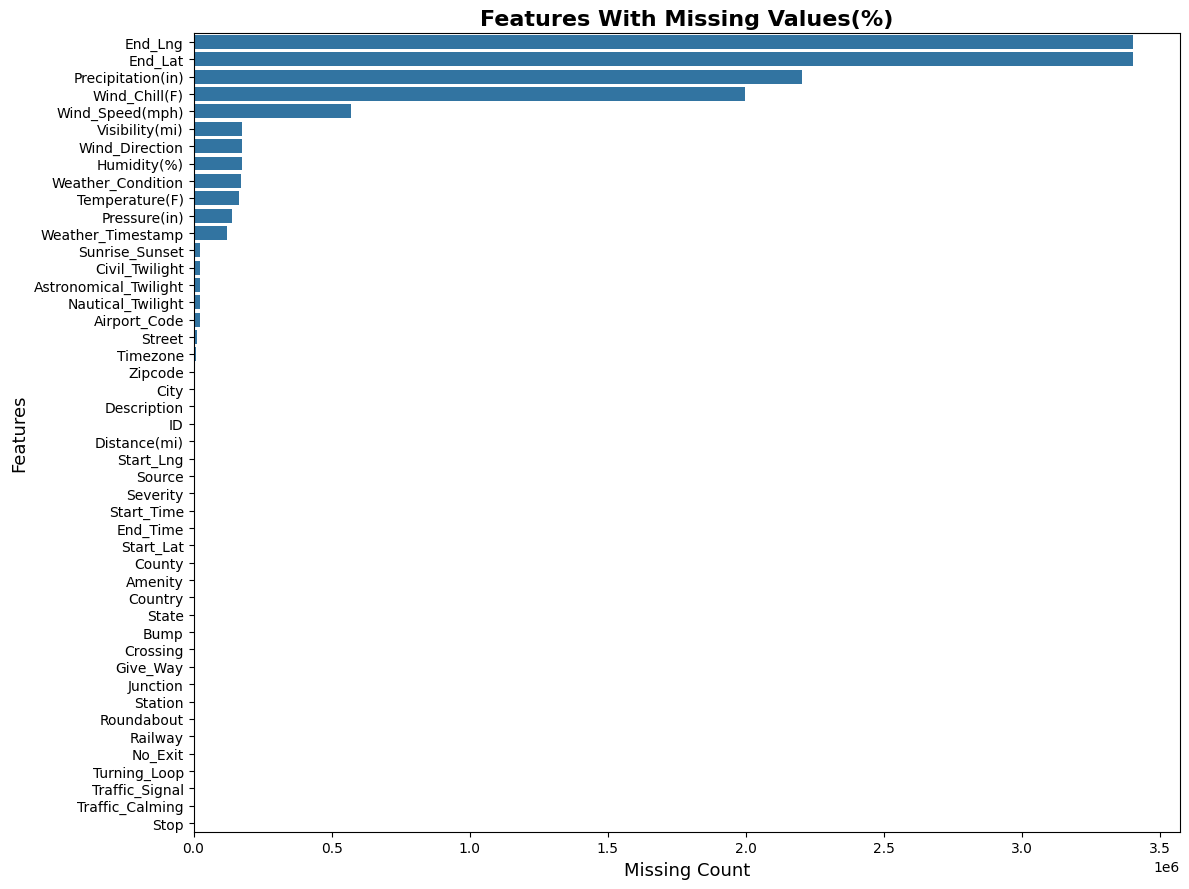

In [14]:
# Visualising the missing values in the dataset
plt.figure(figsize= (12, 9))
sns.barplot(x=total_percent.values, y=total_percent.index)
plt.title("Features With Missing Values(%)", fontsize=16, fontweight="bold")
plt.xlabel("Missing Count", fontsize=13)
plt.ylabel("Features", fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
#Features - "End_Lng" & "End_Lat" hold high percentage of null values.
#Imputing values in them will be unrealistic, thus, these columns will be dropped.

US_acc_severe = US_acc_severe.drop(columns=["End_Lng", "End_Lat"])

In [16]:
#Features: "Precipitation(in)", "Wind_Chill(F)", & "Wind_Speed(mph)".
#They hold numerical values, it would be most appropriate to impute them using median,
#Since dropping the columns or rows will impact the dataset, causing to lose too much valuable data.
numeric_A_impute = ["Precipitation(in)","Wind_Chill(F)", "Wind_Speed(mph)"]

US_acc_severe[numeric_A_impute] = US_acc_severe[numeric_A_impute].fillna(US_acc_severe[numeric_A_impute].median())

In [17]:
#Features: "Visibility(mi)", "Humidity(%)", "Temperature(F)", & "Pressure(in)".
#They hold numerical values, to tackle the missing values median will be used to impute the missing rows.
numeric_B_impute = ["Visibility(mi)", "Humidity(%)", "Temperature(F)", "Pressure(in)"]

US_acc_severe[numeric_B_impute] = US_acc_severe[numeric_B_impute].fillna(US_acc_severe[numeric_B_impute].median())

In [18]:
#Features: "Wind_Direction", "Weather_Condition", "Sunrise_Sunset", "Civil_Twilight", "Astronomical_Twilight", "Nautical_Twilight", & "Airport_Code".
#These are categorical features, to tackle the missing values mode will be used to impute the missing rows.
categoric_impute = ["Wind_Direction", "Weather_Condition", "Sunrise_Sunset", "Civil_Twilight", "Astronomical_Twilight", "Nautical_Twilight", "Airport_Code"]

US_acc_severe[categoric_impute] = US_acc_severe[categoric_impute].fillna(US_acc_severe[categoric_impute].mode().iloc[0])

In [19]:
#Features: "Weather_Timestamp", "Street", "Timezone ", "Zipcode", "City", & "Description".
#The rows from the features will be dropped as they are specific and imputing them with either mode, medium, or mean wont be suitable.

US_acc_severe = US_acc_severe.dropna(subset=["Weather_Timestamp", "Street", "Timezone", "Zipcode", "City", "Description"])

In [20]:
#Checking for any remaining null values
US_acc_severe.isnull().sum().sort_values(ascending=False)

,0
ID,0
Source,0
Severity,0
Start_Time,0
End_Time,0
Start_Lat,0
Start_Lng,0
Distance(mi),0
Description,0
Street,0


In [21]:
#Checking for any duplicate values
US_acc_severe.duplicated().sum()

np.int64(0)

#### Exploratory Data Analysis

##### Univariate

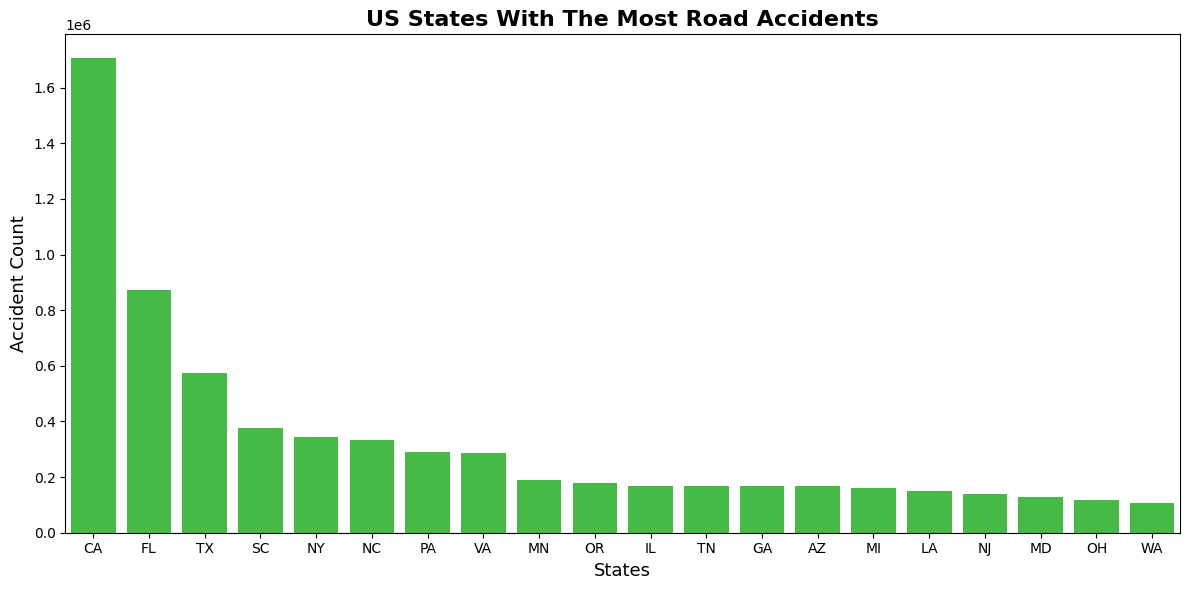

In [22]:
# Top US States with the most road accidents
top_states = US_acc_severe["State"].value_counts()

top_20_states = top_states.head(20)
plt.figure(figsize= (12, 6))
sns.barplot(x=top_20_states.index, y=top_20_states.values, color="limegreen")
plt.title("US States With The Most Road Accidents", fontsize=16, fontweight="bold")
plt.xlabel("States", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.tight_layout()
plt.show()

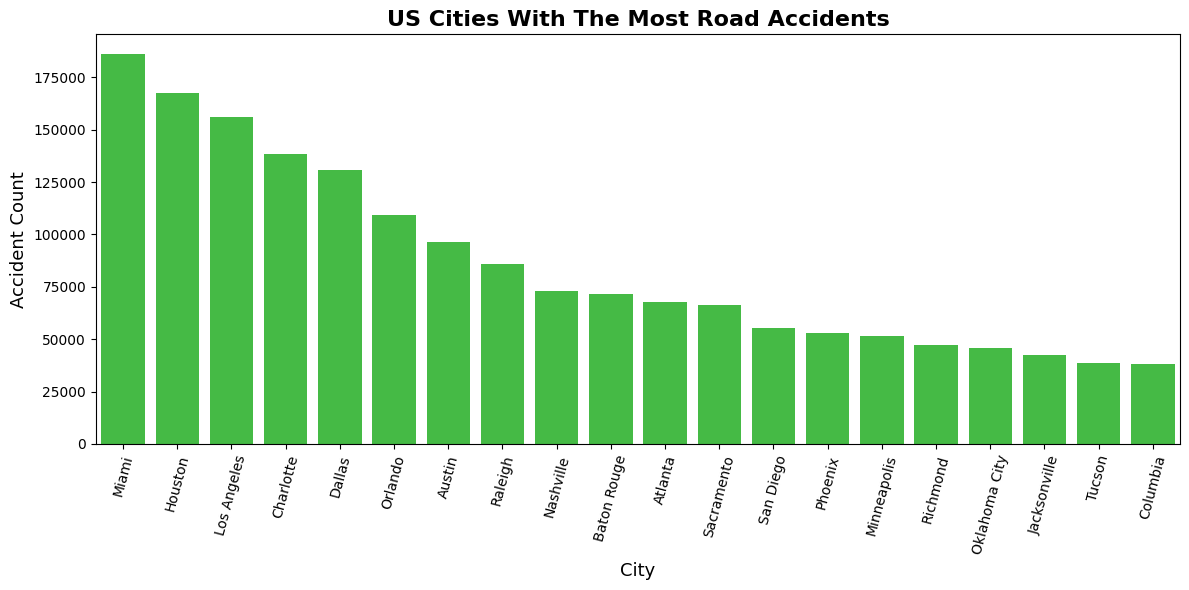

In [23]:
# Top US Cities with the most road accidents
top_city = US_acc_severe["City"].value_counts()

top_20_city = top_city.head(20)
plt.figure(figsize= (12, 6))
sns.barplot(x=top_20_city.index, y=top_20_city.values, color="limegreen")
plt.title("US Cities With The Most Road Accidents", fontsize=16, fontweight="bold")
plt.xlabel("City", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

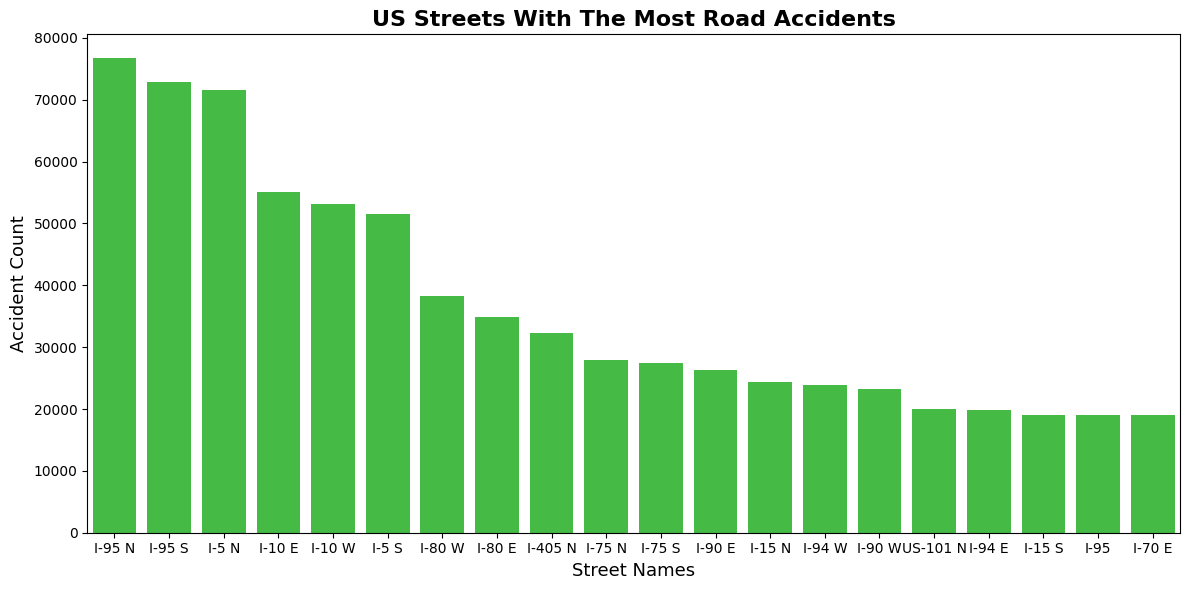

In [24]:
# Top US Streets with the most road accidents
top_street = US_acc_severe["Street"].value_counts()

top_20_street = top_street.head(20)
plt.figure(figsize= (12, 6))
sns.barplot(x=top_20_street.index, y=top_20_street.values, color="limegreen")
plt.title("US Streets With The Most Road Accidents", fontsize=16, fontweight="bold")
plt.xlabel("Street Names", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.tight_layout()
plt.show()

In [25]:
# Formatting Feature: "Start_Time" into datetime format
US_acc_severe.Start_Time = pd.to_datetime(US_acc_severe.Start_Time, format="mixed")

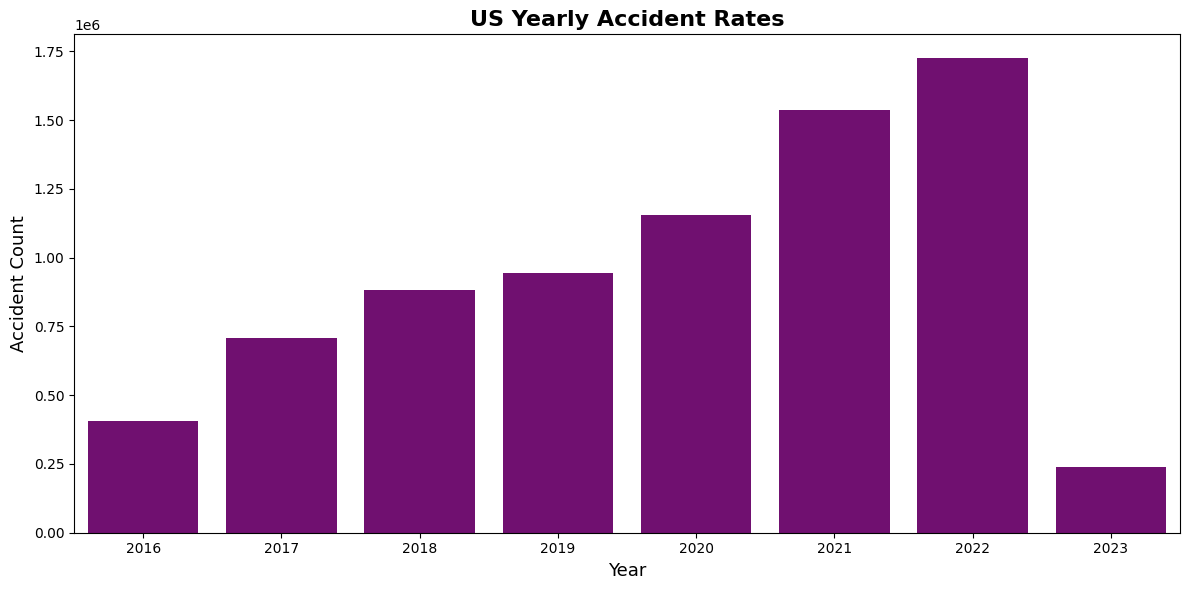

In [26]:
# Yearly road accident rates
yearly_rates = US_acc_severe["Start_Time"].dt.year
yearly_rates = pd.DataFrame(yearly_rates.value_counts()).sort_values(by=["Start_Time"])

plt.figure(figsize= (12, 6))
sns.barplot(x=yearly_rates.index, y=yearly_rates["count"], color="purple")
plt.title("US Yearly Accident Rates", fontsize=16, fontweight="bold")
plt.xlabel("Year", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.tight_layout()
plt.show()

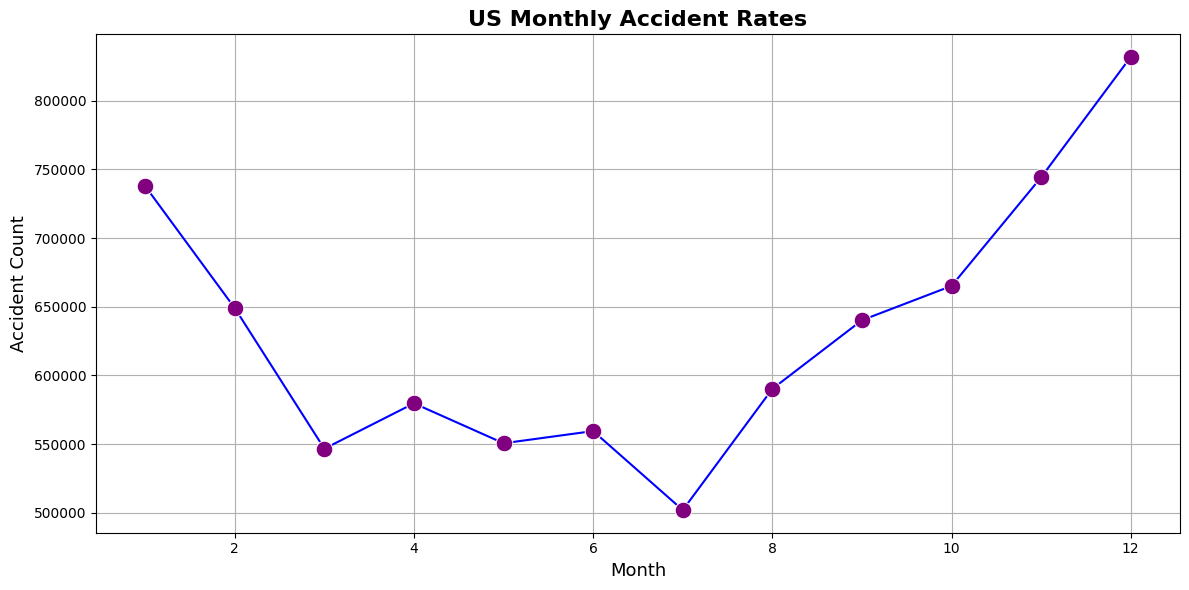

In [27]:
# Monthly road accident rates
monthly_rates = US_acc_severe["Start_Time"].dt.month
monthly_rates = pd.DataFrame(monthly_rates.value_counts()).sort_values(by=["Start_Time"])

plt.figure(figsize= (12, 6))
sns.lineplot(x=monthly_rates.index, y=monthly_rates["count"], marker="o", markersize=12, markerfacecolor="purple", color="blue")
plt.title("US Monthly Accident Rates", fontsize=16, fontweight="bold")
plt.xlabel("Month", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.grid()
plt.tight_layout()
plt.show()

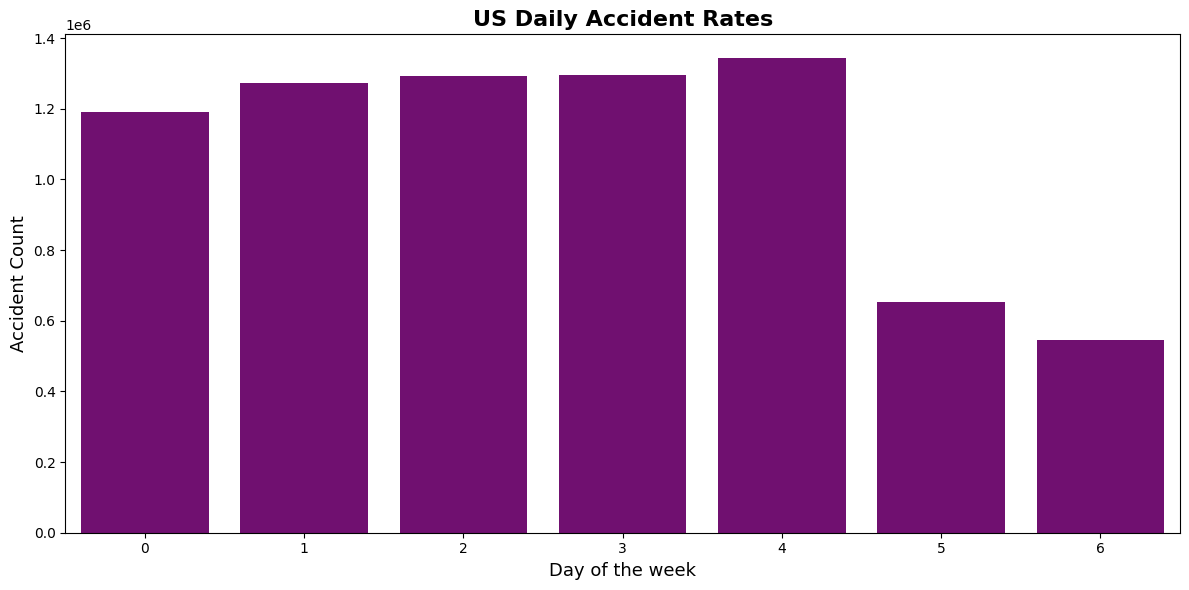

In [28]:
# Daily road accident rates
daily_rates = US_acc_severe["Start_Time"].dt.dayofweek
daily_rates = pd.DataFrame(daily_rates.value_counts()).sort_values(by=["Start_Time"])

plt.figure(figsize= (12, 6))
sns.barplot(x=daily_rates.index, y=daily_rates["count"], color="purple")
plt.title("US Daily Accident Rates", fontsize=16, fontweight="bold")
plt.xlabel("Day of the week", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.tight_layout()
plt.show()

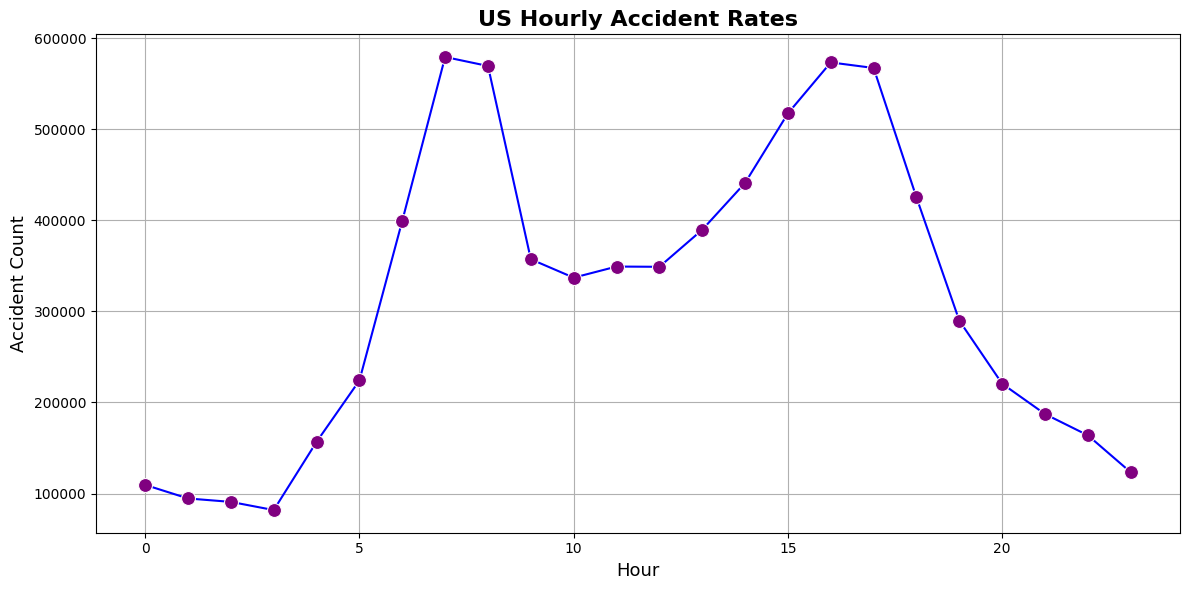

In [29]:
# Hourly road accident rates
hourly_rates = US_acc_severe["Start_Time"].dt.hour
hourly_rates = pd.DataFrame(hourly_rates.value_counts()).sort_values(by=["Start_Time"])

plt.figure(figsize= (12, 6))
sns.lineplot(x=hourly_rates.index, y=hourly_rates["count"], marker="o", markersize=10, markerfacecolor="purple", color="blue")
plt.title("US Hourly Accident Rates", fontsize=16, fontweight="bold")
plt.xlabel("Hour", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.grid()
plt.tight_layout()
plt.show()

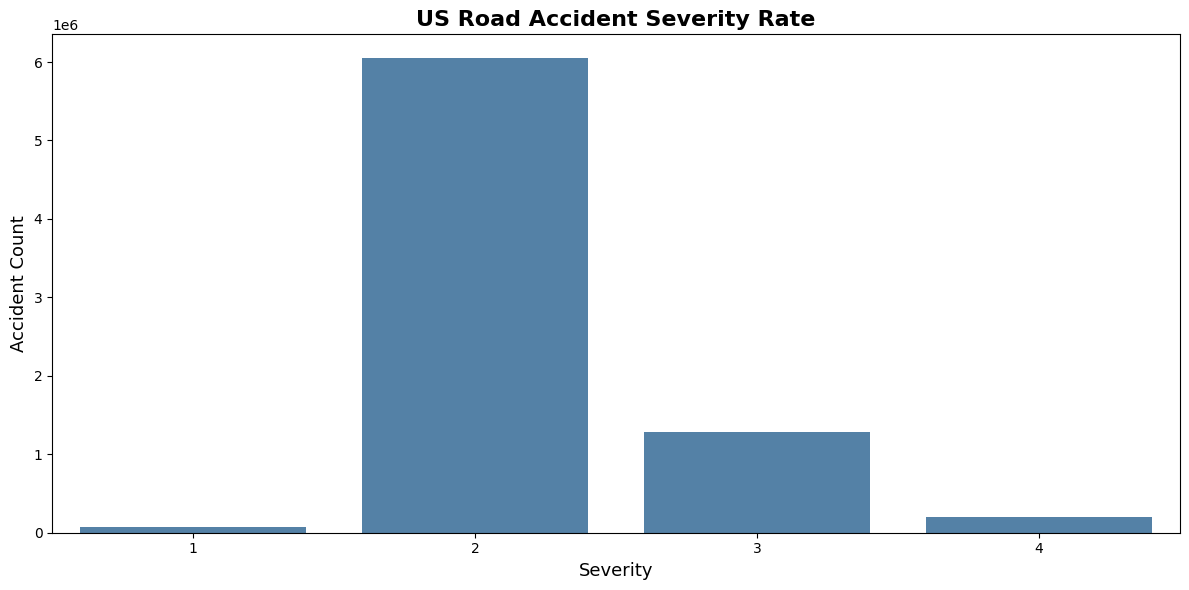

In [30]:
# Top US Streets with the most road accidents
accident_severe = US_acc_severe["Severity"].value_counts()

plt.figure(figsize= (12, 6))
sns.barplot(x=accident_severe.index, y=accident_severe.values, color="steelblue")
plt.title("US Road Accident Severity Rate", fontsize=16, fontweight="bold")
plt.xlabel("Severity", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.tight_layout()
plt.show()

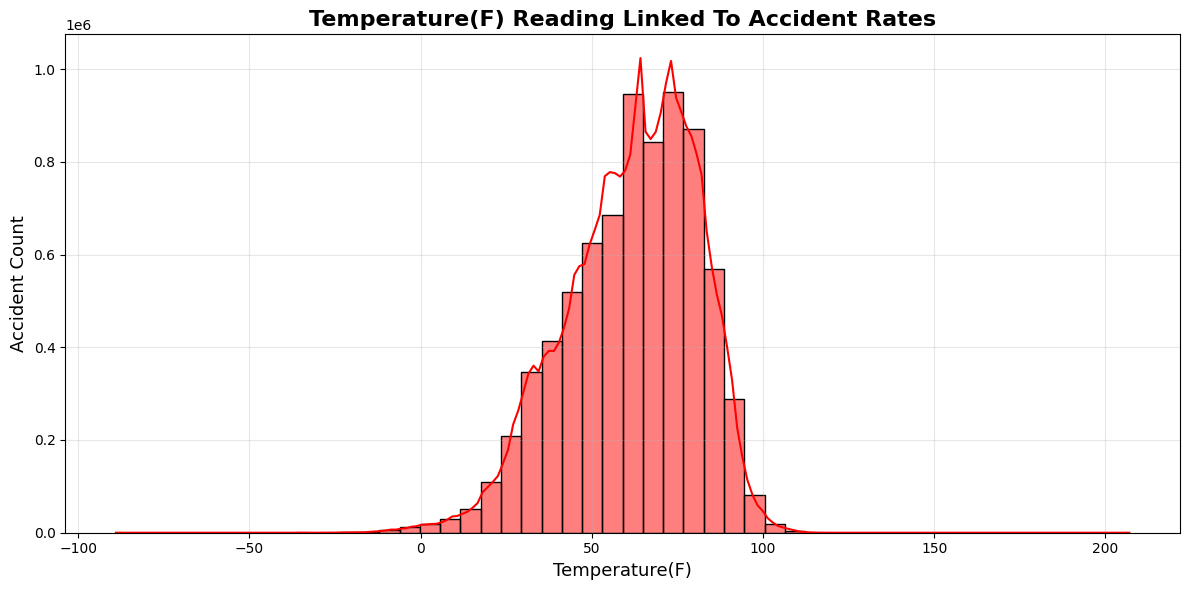

In [31]:
# At what temperature do most US road accidents take place
temp_reading = US_acc_severe["Temperature(F)"]

plt.figure(figsize= (12, 6))
sns.histplot(data=temp_reading, kde=True, bins=50, color="red")
plt.title("Temperature(F) Reading Linked To Accident Rates", fontsize=16, fontweight="bold")
plt.xlabel("Temperature(F)", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

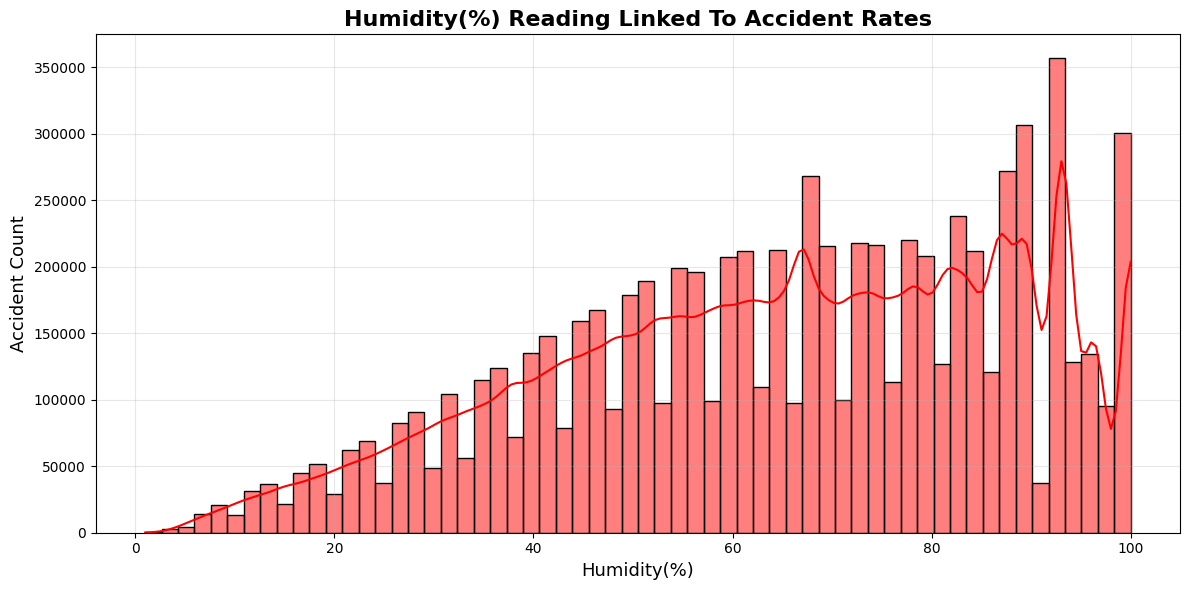

In [32]:
# At what humidity level do most US road accidents take place
humid_reading = US_acc_severe["Humidity(%)"]

plt.figure(figsize= (12, 6))
sns.histplot(data=humid_reading, kde=True, bins=60, color="red")
plt.title("Humidity(%) Reading Linked To Accident Rates", fontsize=16, fontweight="bold")
plt.xlabel("Humidity(%)", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

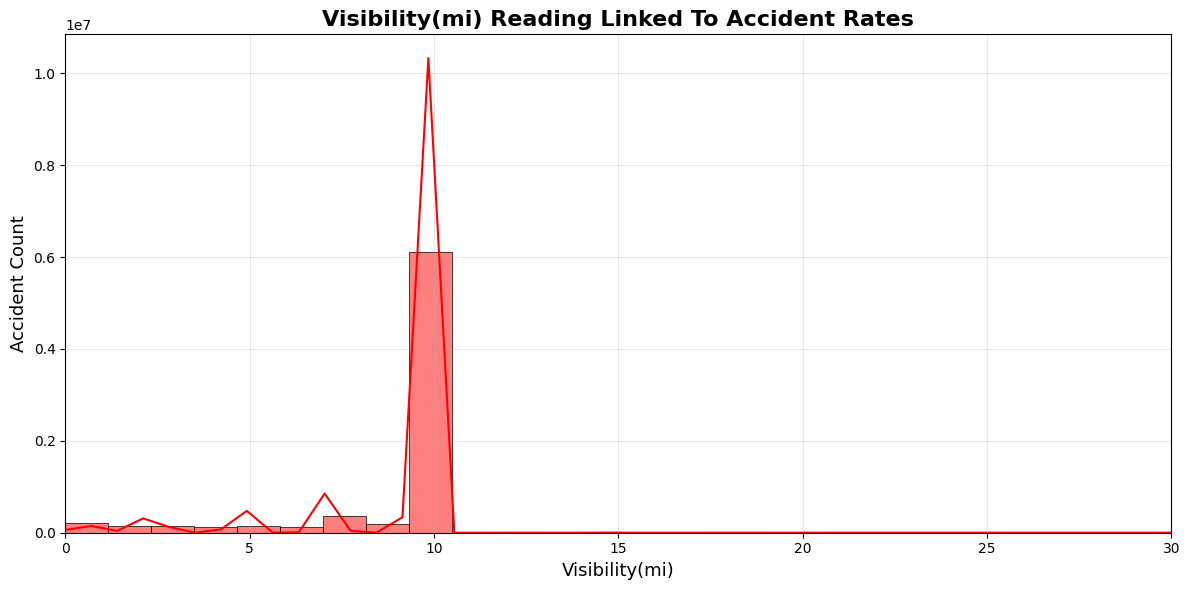

In [33]:
# At what visibility level do most US road accidents take place
visib_reading = US_acc_severe["Visibility(mi)"]

plt.figure(figsize= (12, 6))
sns.histplot(data=visib_reading, kde=True, bins=120, color="red")
plt.title("Visibility(mi) Reading Linked To Accident Rates", fontsize=16, fontweight="bold")
plt.xlabel("Visibility(mi)", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.xlim(0, 30)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

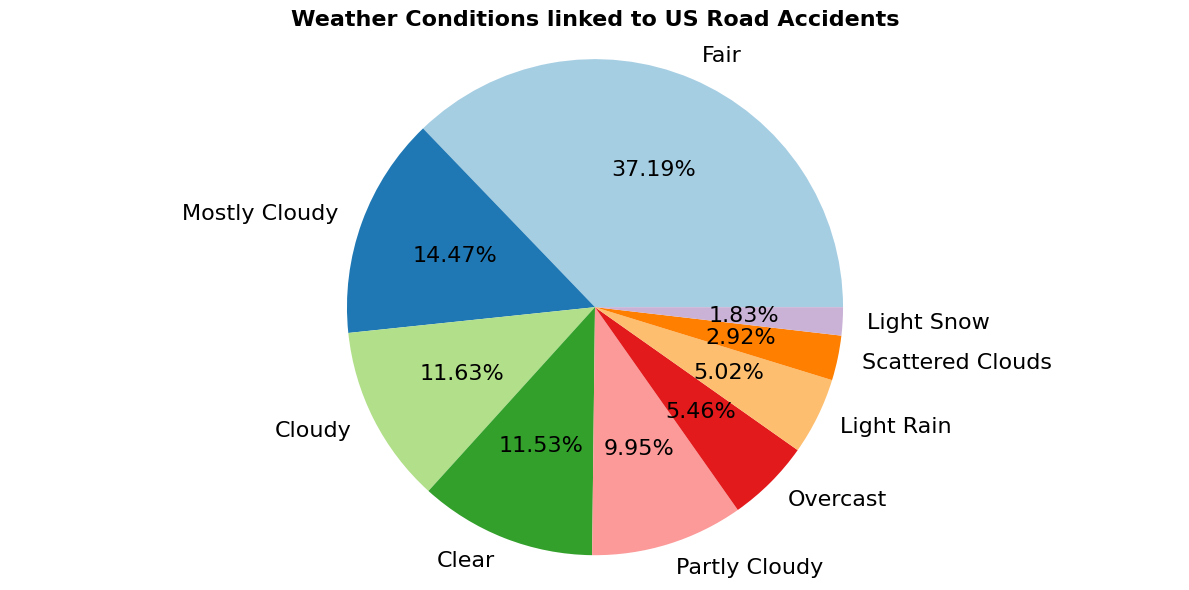

In [34]:
# At what weather condition do most US road accidents take place
weather_condit = US_acc_severe["Weather_Condition"].value_counts().head(9)

plt.figure(figsize= (12, 6))
plt.pie(weather_condit, labels=weather_condit.index, colors=sns.color_palette("Paired"), autopct="%1.2f%%", textprops={"fontsize":16})
plt.title("Weather Conditions linked to US Road Accidents", fontsize=16, fontweight="bold")
plt.axis("equal")
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

##### Bivariate

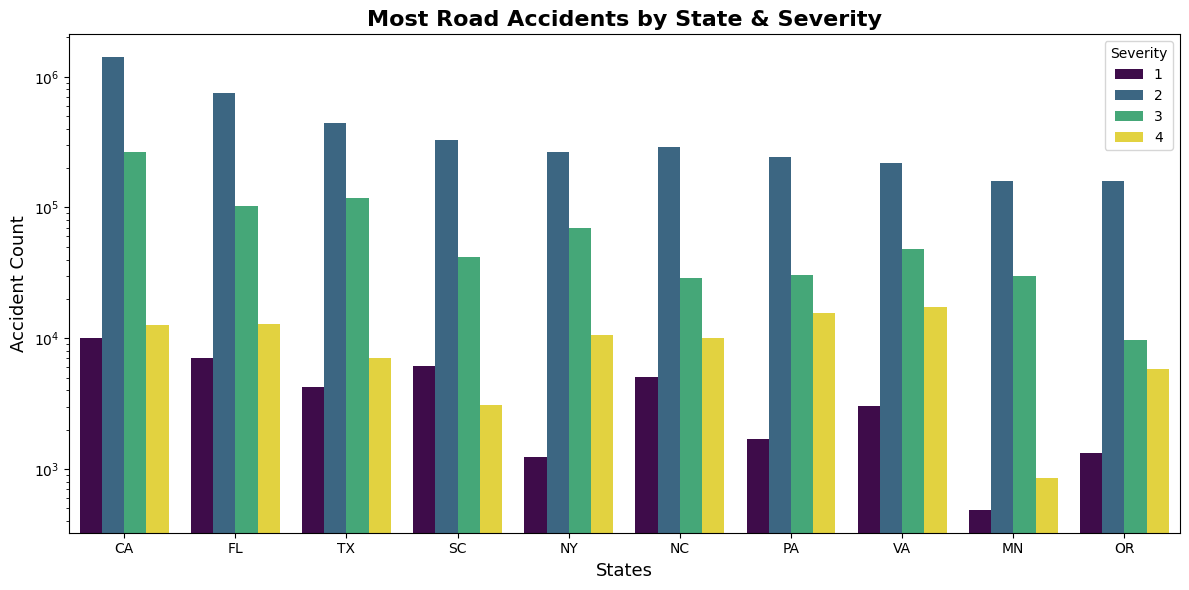

In [35]:
# Most Road Accidents by State & Severity
states_v_severe = US_acc_severe["State"].value_counts().head(10).index

plt.figure(figsize= (12, 6))
sns.countplot(data=US_acc_severe, x="State", hue="Severity", order=states_v_severe, palette="viridis")
plt.title("Most Road Accidents by State & Severity", fontsize=16, fontweight="bold")
plt.xlabel("States", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.yscale("log")
plt.tight_layout()
plt.show()

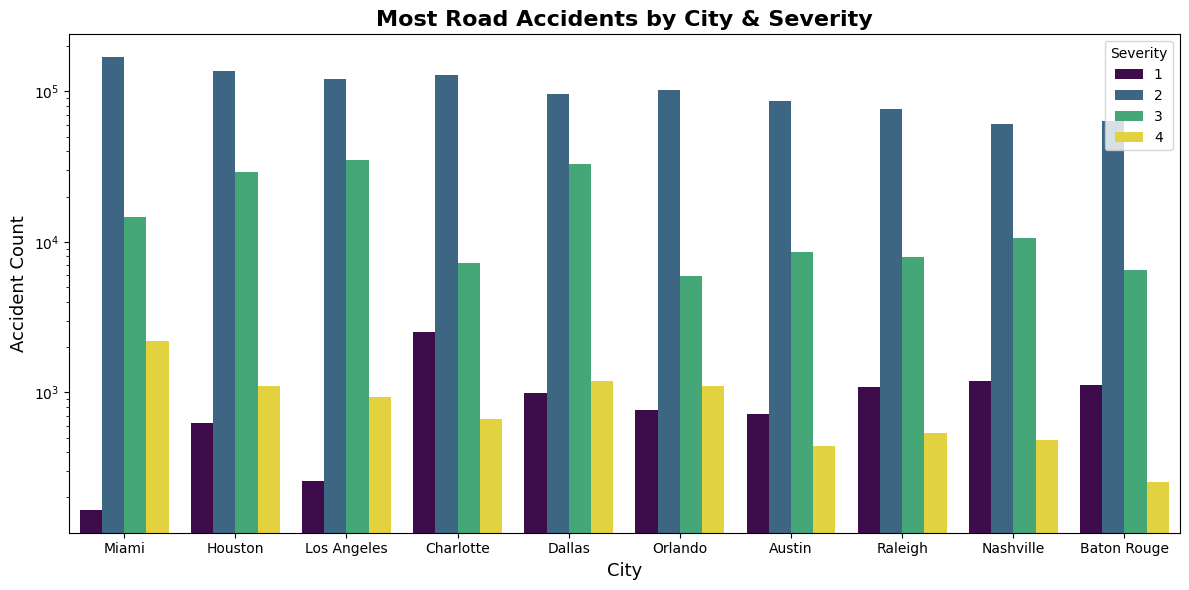

In [36]:
# Most Road Accidents by City & Severity
city_v_severe = US_acc_severe["City"].value_counts().head(10).index

plt.figure(figsize= (12, 6))
sns.countplot(data=US_acc_severe, x="City", hue="Severity", order=city_v_severe, palette="viridis")
plt.title("Most Road Accidents by City & Severity", fontsize=16, fontweight="bold")
plt.xlabel("City", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.yscale("log")
plt.tight_layout()
plt.show()

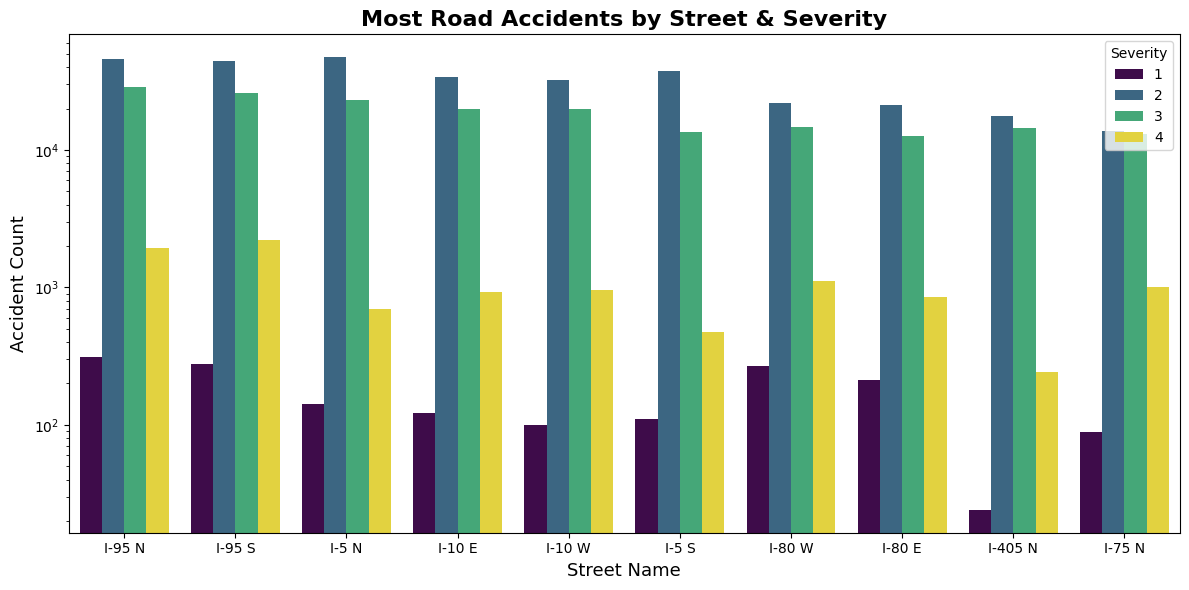

In [37]:
# Most Road Accidents by Street & Severity
street_v_severe = US_acc_severe["Street"].value_counts().head(10).index

plt.figure(figsize= (12, 6))
sns.countplot(data=US_acc_severe, x="Street", hue="Severity", order=street_v_severe, palette="viridis")
plt.title("Most Road Accidents by Street & Severity", fontsize=16, fontweight="bold")
plt.xlabel("Street Name", fontsize=13)
plt.ylabel("Accident Count", fontsize=13)
plt.yscale("log")
plt.tight_layout()
plt.show()

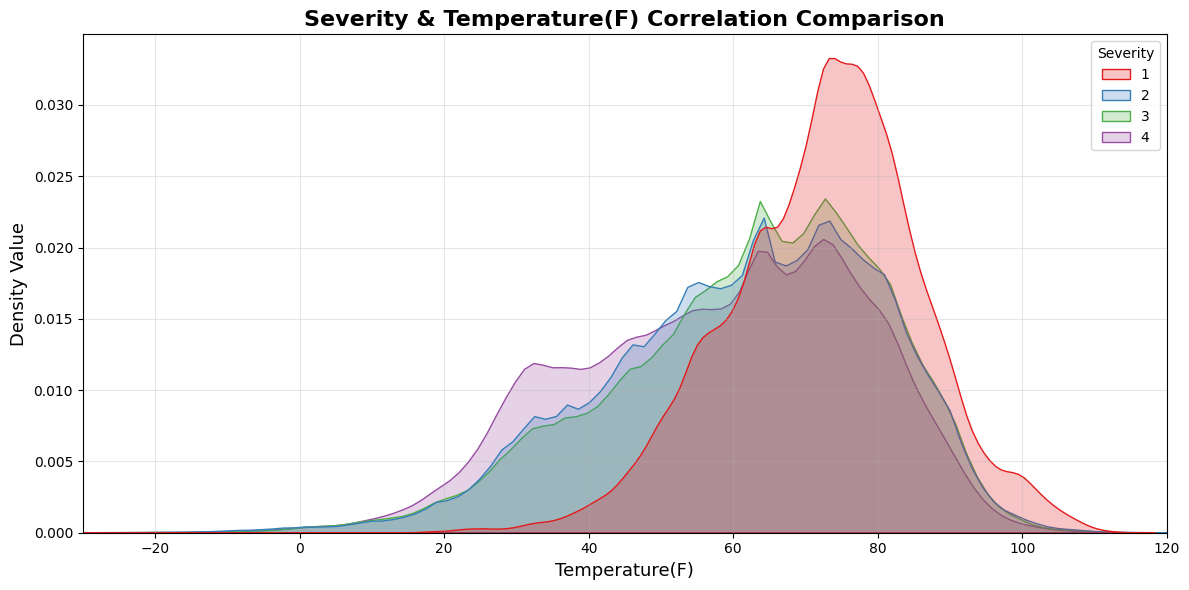

In [38]:
# Visualising the correlation between temperature + severity on how it affects US road accidents
plt.figure(figsize= (12, 6))
sns.kdeplot(data=US_acc_severe, x= "Temperature(F)", hue= "Severity", palette="Set1", common_norm=False, fill=True)
plt.title("Severity & Temperature(F) Correlation Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Temperature(F)", fontsize=13)
plt.ylabel("Density Value", fontsize=13)
plt.xlim(-30, 120)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

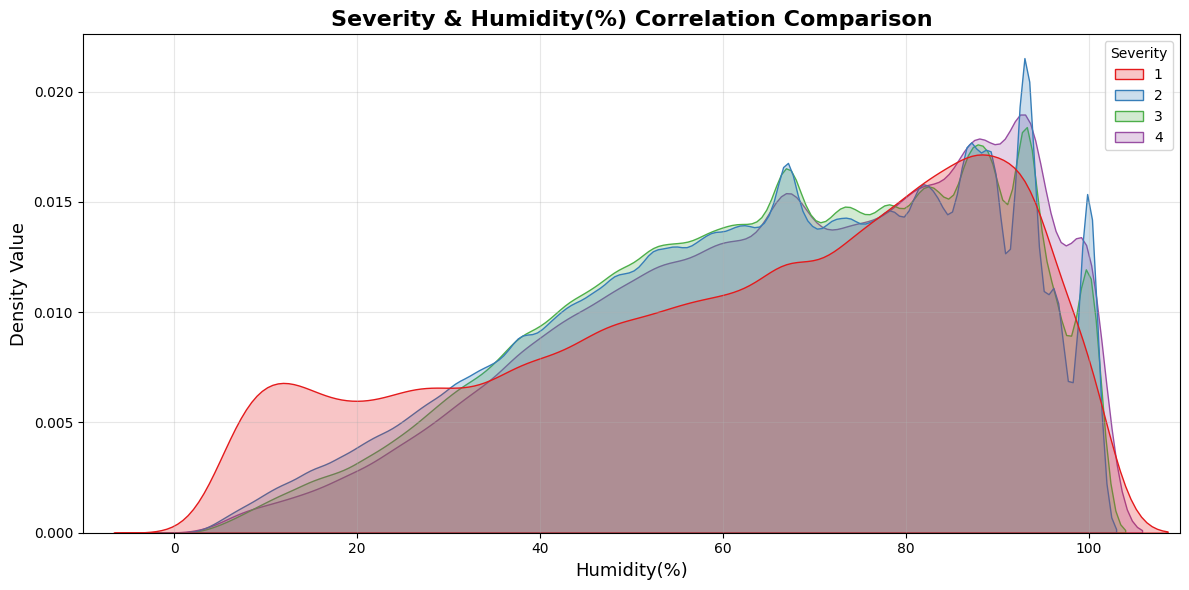

In [39]:
# Visualising the correlation between humidity + severity on how it affects US road accidents
plt.figure(figsize= (12, 6))
sns.kdeplot(data=US_acc_severe, x= "Humidity(%)", hue= "Severity", palette="Set1", common_norm=False, fill=True)
plt.title("Severity & Humidity(%) Correlation Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Humidity(%)", fontsize=13)
plt.ylabel("Density Value", fontsize=13)
plt.xlim(-10, 110)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

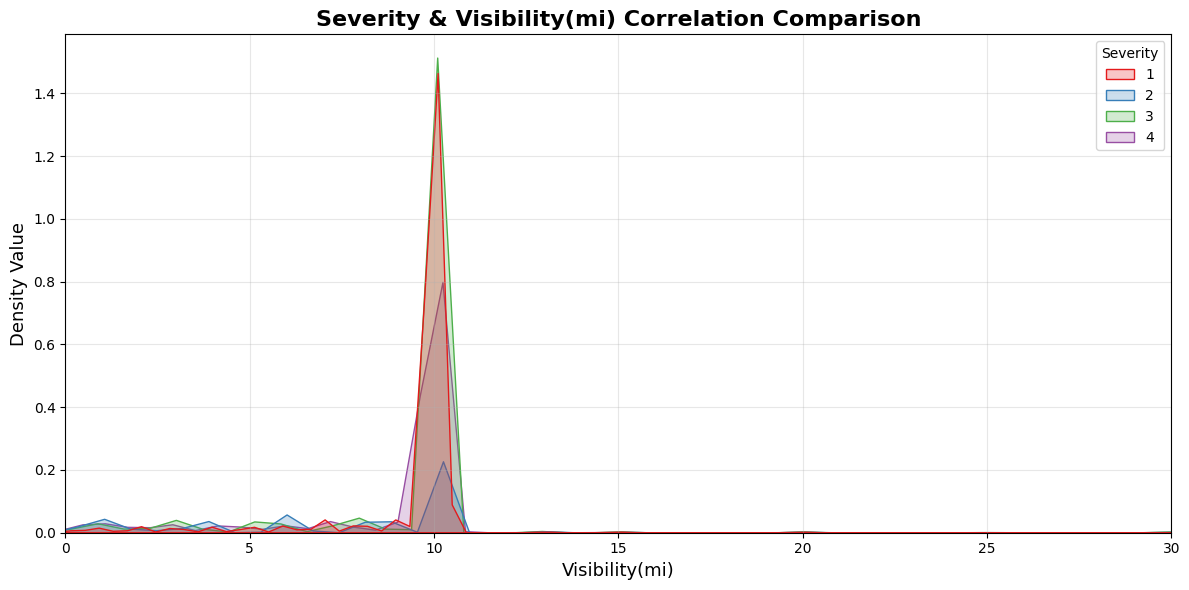

In [40]:
# Visualising the correlation between visibility + severity on how it affects US road accidents
plt.figure(figsize= (12, 6))
sns.kdeplot(data=US_acc_severe, x= "Visibility(mi)", hue= "Severity", palette="Set1", common_norm=False, fill=True)
plt.title("Severity & Visibility(mi) Correlation Comparison", fontsize=16, fontweight="bold")
plt.xlabel("Visibility(mi)", fontsize=13)
plt.ylabel("Density Value", fontsize=13)
plt.xlim(0, 30)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

##### Multivariate

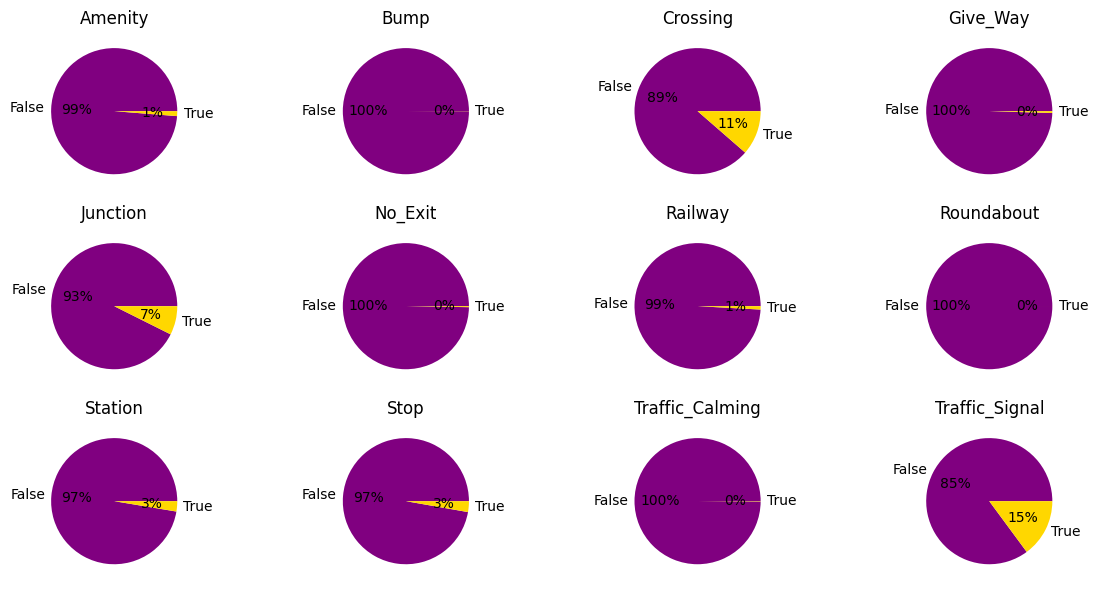

In [41]:
# Visualising various location based factors that contribute to accidents
factor_based_feat = ["Amenity", "Bump", "Crossing", "Give_Way", "Junction", "No_Exit", "Railway", "Roundabout", "Station", "Stop", "Traffic_Calming", "Traffic_Signal"]
fig, ax = plt.subplots(figsize=(12, 6), ncols=4, nrows=3, sharex=True, sharey=True)
ax_flattening = ax.flatten()

for n, feature in enumerate(factor_based_feat):
    multi_pie_diagram = ax_flattening[n]
    multi_pie_diagram_val = US_acc_severe[feature].value_counts()
    multi_pie_diagram_color = ["purple", "gold"]
    multi_pie_diagram.pie(multi_pie_diagram_val, labels=multi_pie_diagram_val.index, autopct="%1.0f%%", colors=multi_pie_diagram_color)
    multi_pie_diagram.set_title(feature)
plt.tight_layout()
plt.show()

/tmp/ipykernel_9462/2882802165.py:5: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


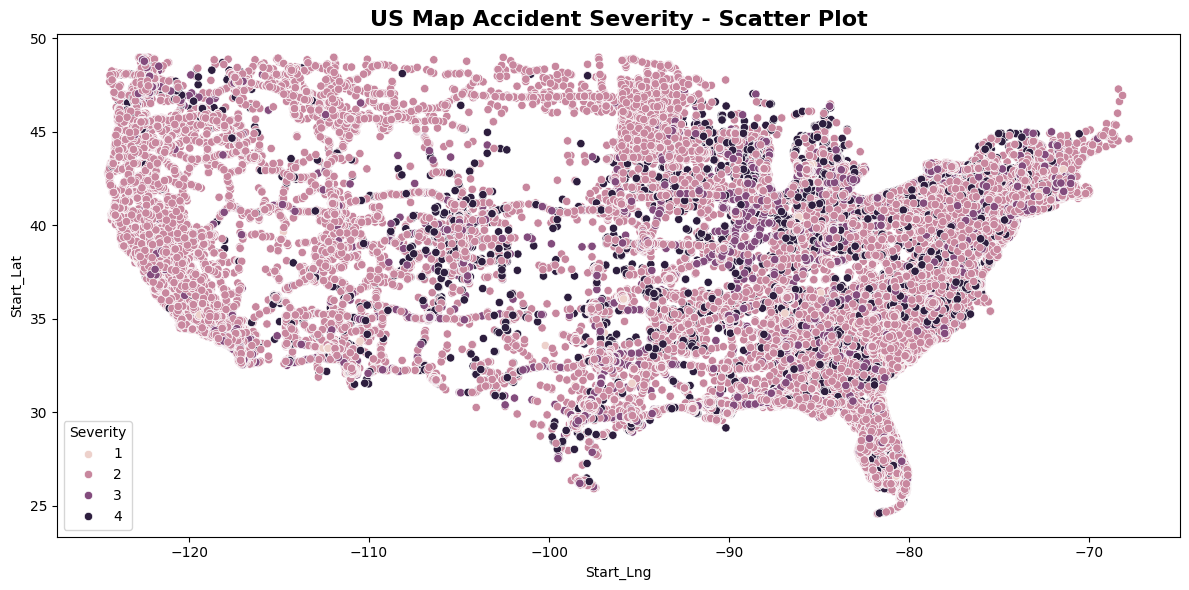

In [42]:
# US Map - Accident scatter plot by Start Lng, Start Lat & Severity
plt.figure(figsize= (12, 6))
sns.scatterplot(data=US_acc_severe.sample(1000000), x="Start_Lng", y="Start_Lat", hue="Severity")
plt.title("US Map Accident Severity - Scatter Plot", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

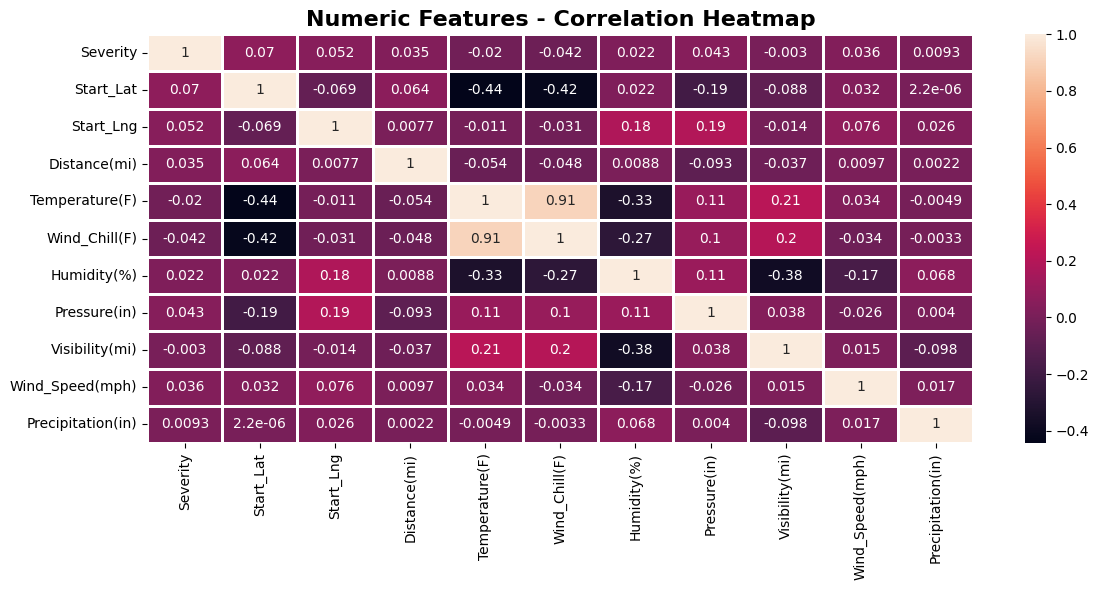

In [43]:
# Visualising numeric feature correlation - Heatmap
us_numeric_type = US_acc_severe.select_dtypes(include=["int64", "float64"])

plt.figure(figsize= (12, 6))
sns.heatmap(us_numeric_type.corr(), annot=True, linewidths=1)
plt.title("Numeric Features - Correlation Heatmap", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

#### Data Preprocessing

##### Outlier Treatment

In [44]:
US_acc_severe.describe()

,Severity,Start_Time,Start_Lat,Start_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.597276e+06,7597276,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06
mean,2.212300e+00,2020-06-01 12:01:44.684660736,3.619215e+01,-9.468373e+01,5.578309e-01,6.167704e+01,5.917548e+01,6.484831e+01,2.954022e+01,9.097258e+00,7.644913e+00,6.104809e-03
min,1.000000e+00,2016-01-14 20:18:33,2.455480e+01,-1.246238e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,2018-11-20 07:21:12.500000,3.338558e+01,-1.172087e+02,0.000000e+00,4.900000e+01,5.200000e+01,4.800000e+01,2.937000e+01,1.000000e+01,5.000000e+00,0.000000e+00
50%,2.000000e+00,2020-11-09 16:59:00,3.580487e+01,-8.776320e+01,2.800000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,2022-01-18 14:50:00,4.009566e+01,-8.036949e+01,4.590000e-01,7.600000e+01,7.100000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.000000e+01,0.000000e+00
max,4.000000e+00,2023-03-31 23:30:00,4.900220e+01,-6.711317e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01
std,4.870028e-01,NaN,5.092885e+00,1.736801e+01,1.767564e+00,1.896026e+01,1.949498e+01,2.273928e+01,1.004603e+00,2.679841e+00,5.263022e+00,9.405786e-02


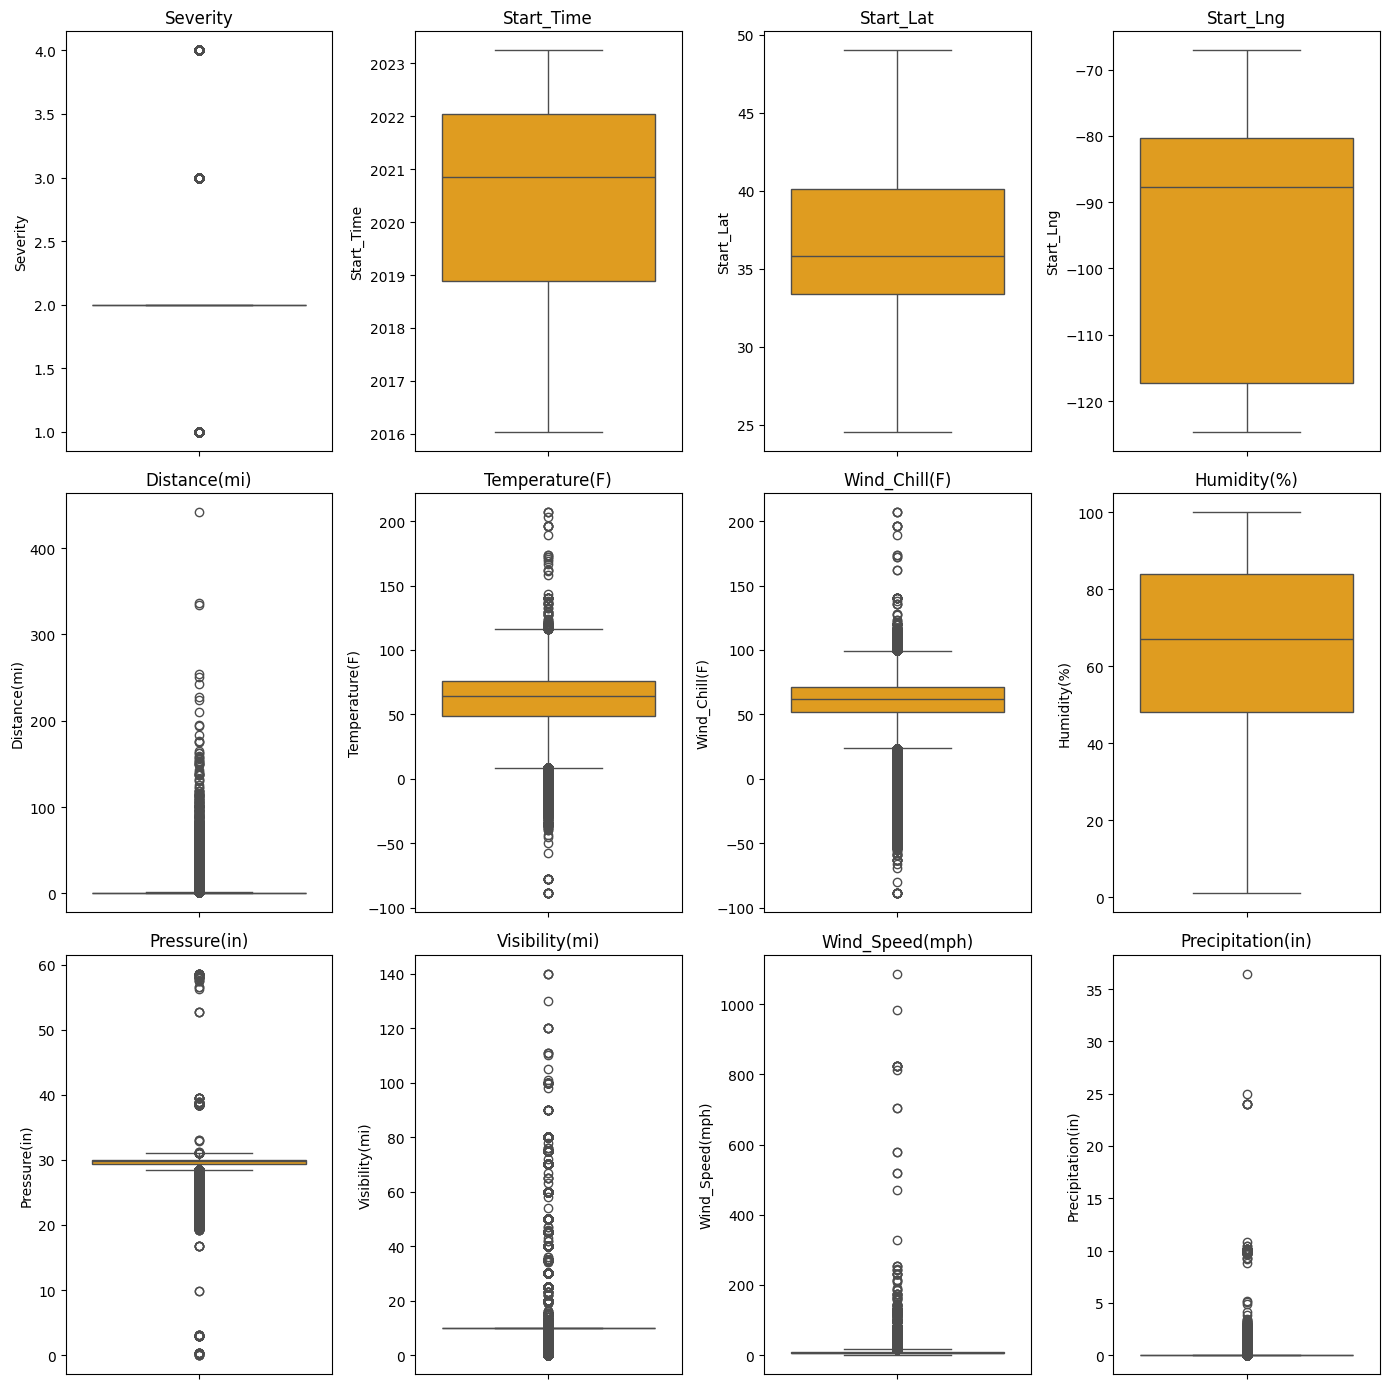

In [45]:
# Visualising potential outliers
plot_potential_outliers = ["Severity", "Start_Time", "Start_Lat", "Start_Lng", "Distance(mi)", "Temperature(F)",
                           "Wind_Chill(F)", "Humidity(%)", "Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)"]

fig, ax = plt.subplots(ncols=4, nrows=3, figsize=(14, 14))
ax_flat = ax.flatten()

for n, cols in enumerate(plot_potential_outliers):
    sns.boxplot(data=US_acc_severe, y=cols, ax=ax_flat[n], color="orange")
    ax_flat[n].set_title(cols)
plt.tight_layout()
plt.show()

In [46]:
# Features: "Severity", "Start_Time", "Start_Lat", "Start_Lng", & "Humidity(%)" will not require any outlier treatment.
# However, features: "Distance(mi)", "Temperature(F)", "Wind_Chill(F)", "Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)"
# will need to outlier treatment - Winsorization

treatment_features = ["Distance(mi)", "Temperature(F)", "Wind_Chill(F)", "Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)"]
for cols in treatment_features:
    low_val, upp_val = US_acc_severe[cols].quantile([0.01, 0.99])
    US_acc_severe[cols] = US_acc_severe[cols].clip(lower=low_val, upper=upp_val)

In [47]:
US_acc_severe.describe()

,Severity,Start_Time,Start_Lat,Start_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.597276e+06,7597276,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06,7.597276e+06
mean,2.212300e+00,2020-06-01 12:01:44.684660736,3.619215e+01,-9.468373e+01,5.029359e-01,6.172287e+01,5.924769e+01,6.484831e+01,2.954748e+01,9.043848e+00,7.609194e+00,3.714660e-03
min,1.000000e+00,2016-01-14 20:18:33,2.455480e+01,-1.246238e+02,0.000000e+00,1.220000e+01,2.000000e+00,1.000000e+00,2.458000e+01,5.000000e-01,0.000000e+00,0.000000e+00
25%,2.000000e+00,2018-11-20 07:21:12.500000,3.338558e+01,-1.172087e+02,0.000000e+00,4.900000e+01,5.200000e+01,4.800000e+01,2.937000e+01,1.000000e+01,5.000000e+00,0.000000e+00
50%,2.000000e+00,2020-11-09 16:59:00,3.580487e+01,-8.776320e+01,2.800000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,2022-01-18 14:50:00,4.009566e+01,-8.036949e+01,4.590000e-01,7.600000e+01,7.100000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.000000e+01,0.000000e+00
max,4.000000e+00,2023-03-31 23:30:00,4.900220e+01,-6.711317e+01,6.918000e+00,9.600000e+01,9.400000e+01,1.000000e+02,3.044000e+01,1.000000e+01,2.300000e+01,1.400000e-01
std,4.870028e-01,NaN,5.092885e+00,1.736801e+01,1.125074e+00,1.861664e+01,1.898878e+01,2.273928e+01,9.486648e-01,2.320362e+00,4.980852e+00,1.837201e-02


##### Feature Engineering

In [48]:
# Dropping feature that dont add value:"ID", "Country", "Description"
# ID - is unique identifier, which wont help with evaluation
# Country - the dataset values are collected from US, so this feature is redundant
# Description - there are other columns that provide more information with regards to the accident

US_acc_severe = US_acc_severe.drop(columns=["ID", "Country", "Description"])

In [49]:
US_acc_severe.shape

(7597276, 41)

##### Feature Encoding

In [50]:
# Converting this feature into string data type
US_acc_severe["Start_Time"] = US_acc_severe["Start_Time"].astype(str)

In [51]:
# Bool & str/object will need to be categorised into numerical values
category_col = US_acc_severe.select_dtypes(include=["object", "bool"]).columns
print(category_col)

Index(['Source', 'Start_Time', 'End_Time', 'Street', 'City', 'County', 'State',
       'Zipcode', 'Timezone', 'Airport_Code', 'Weather_Timestamp',
       'Wind_Direction', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing',
       'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station',
       'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop',
       'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')


In [52]:
# Using label encoding to convert object & str dtypes into numerical dtypes
encode_cols = LabelEncoder()

for cols in category_col:
    US_acc_severe[cols] = encode_cols.fit_transform(US_acc_severe[cols])

In [53]:
US_acc_severe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7597276 entries, 0 to 7728393
Data columns (total 41 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Source                 int64  
 1   Severity               int64  
 2   Start_Time             int64  
 3   End_Time               int64  
 4   Start_Lat              float64
 5   Start_Lng              float64
 6   Distance(mi)           float64
 7   Street                 int64  
 8   City                   int64  
 9   County                 int64  
 10  State                  int64  
 11  Zipcode                int64  
 12  Timezone               int64  
 13  Airport_Code           int64  
 14  Weather_Timestamp      int64  
 15  Temperature(F)         float64
 16  Wind_Chill(F)          float64
 17  Humidity(%)            float64
 18  Pressure(in)           float64
 19  Visibility(mi)         float64
 20  Wind_Direction         int64  
 21  Wind_Speed(mph)        float64
 22  Precipitation(in)      

#### Model Training and Testing

In [54]:
X = US_acc_severe.drop("Severity", axis=1).copy()
y = US_acc_severe["Severity"].copy()

In [55]:
y.unique()

array([3, 2, 1, 4])

In [56]:
# Subtracting 1 from y so that the severity label starts with 0
y = y - 1

In [57]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [58]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((6077820, 40), (1519456, 40), (6077820,), (1519456,))

In [59]:
# Apply feature scaling via StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

##### Model 1 - ANN (Experimental)

In [60]:
# Model 1 - ANN (Experiment)
def ann_1_experiment_model(num_classes = 4):
    model = tf.keras.Sequential()
    model.add(keras.Input(shape=(X_train.shape[1],)))
    # Adding hidden layers
    model.add(layers.Dense(256, activation="relu"))
    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dense(64, activation="relu"))
    model.add(layers.Dense(num_classes, activation="softmax"))
    # Compiling the model
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model
# To train the model
model_building = ann_1_experiment_model()
model_history = model_building.fit(X_train, Y_train, validation_split=0.2, epochs=10, batch_size=256, callbacks=[tf.keras.callbacks.ReduceLROnPlateau()])

Epoch 1/10
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 67s 3ms/step - accuracy: 0.8658 - loss: 0.3315 - val_accuracy: 0.8753 - val_loss: 0.3098 - learning_rate: 0.0010
Epoch 2/10
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - accuracy: 0.8780 - loss: 0.3041 - val_accuracy: 0.8807 - val_loss: 0.2988 - learning_rate: 0.0010
Epoch 3/10
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - accuracy: 0.8822 - loss: 0.2952 - val_accuracy: 0.8835 - val_loss: 0.2927 - learning_rate: 0.0010
Epoch 4/10
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - accuracy: 0.8847 - loss: 0.2897 - val_accuracy: 0.8852 - val_loss: 0.2895 - learning_rate: 0.0010
Epoch 5/10
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - accuracy: 0.8864 - loss: 0.2859 - val_accuracy: 0.8872 - val_loss: 0.2850 - learning_rate: 0.0010
Epoch 6/10
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - accuracy: 0.8877 - loss: 0.2829 - val_accuracy: 0.8871 - val_loss: 0.2851 - learning_rate: 0.0010
Epoch 7/10
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step -

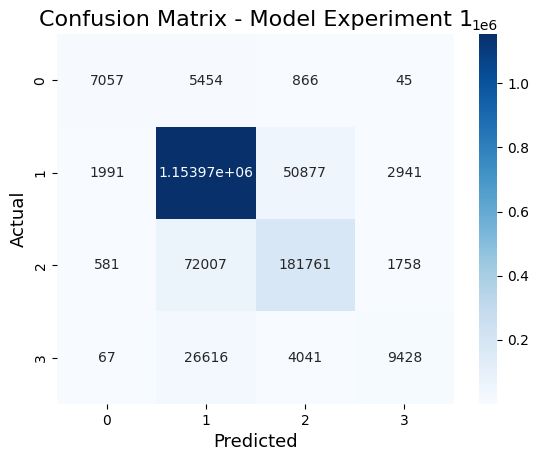

In [62]:
# Getting models prediction
y_prob = model_building.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

#from this get the confusion matrix
model_confuse_mat = confusion_matrix(Y_test, y_pred)
sns.heatmap(model_confuse_mat, annot=True, fmt="g", cmap="Blues")
plt.ylabel("Actual", fontsize=13)
plt.xlabel("Predicted", fontsize=13)
plt.title("Confusion Matrix - Model Experiment 1", fontsize=16)
plt.show()

In [63]:
# Also obtain the classification report
print("Model Experiment 1 (Classification report): ")
print(classification_report(Y_test, y_pred))

Model Experiment 1 (Classification report): 
              precision    recall  f1-score   support

           0       0.73      0.53      0.61     13422
           1       0.92      0.95      0.94   1209775
           2       0.77      0.71      0.74    256107
           3       0.67      0.23      0.35     40152

    accuracy                           0.89   1519456
   macro avg       0.77      0.61      0.66   1519456
weighted avg       0.88      0.89      0.88   1519456



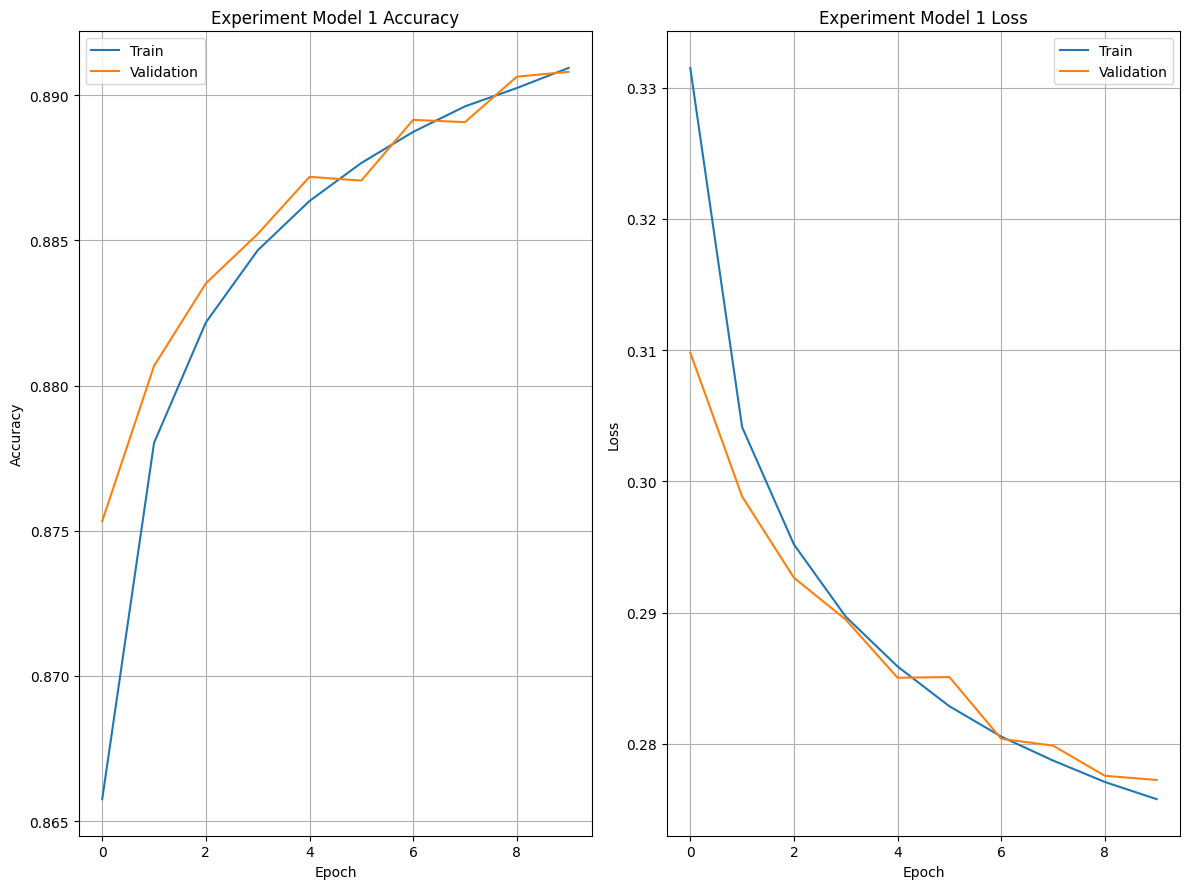

In [64]:
# Plotting the Learning graph of Model 1
fig, (ax1, ax2) = plt.subplots(figsize=(12, 9), ncols=2, nrows=1)
ax1.plot(model_history.history["accuracy"], label="Train")
ax1.plot(model_history.history["val_accuracy"], label="Validation")
ax1.set_title("Experiment Model 1 Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid()

ax2.plot(model_history.history["loss"], label="Train")
ax2.plot(model_history.history["val_loss"], label="Validation")
ax2.set_title("Experiment Model 1 Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

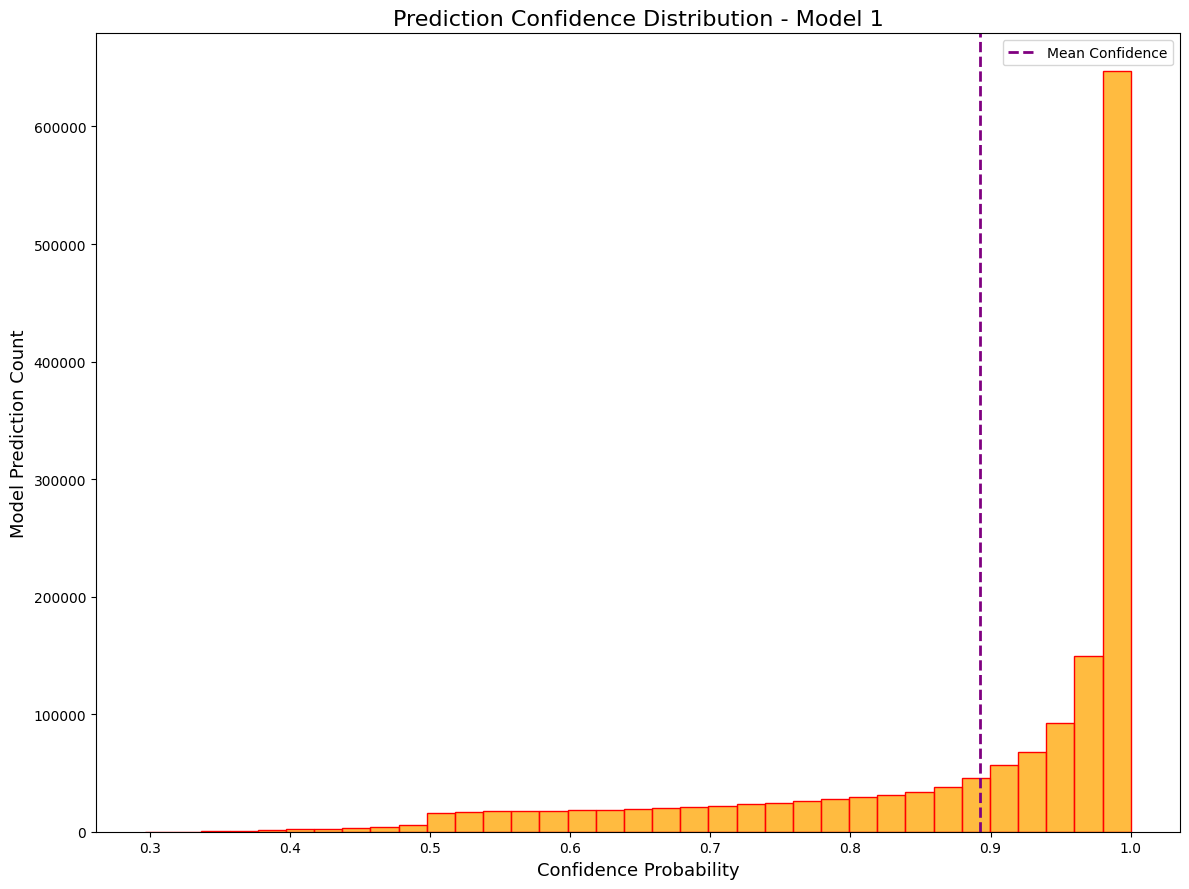

In [65]:
# Obtain models prediction confidence - Model 1
y_pred = np.max(y_prob, axis=1)
convert_to_dataframe = pd.Series(y_pred)

# Plot the model prediction confidence
plt.figure(figsize=(12, 9))
sns.histplot(data=convert_to_dataframe, color="orange", edgecolor="red", bins=35)
plt.axvline(convert_to_dataframe.mean(), color="purple", linestyle="dashed", linewidth=2, label="Mean Confidence")
plt.title("Prediction Confidence Distribution - Model 1", fontsize=16)
plt.xlabel("Confidence Probability", fontsize=13)
plt.ylabel("Model Prediction Count", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

##### Model 2 - ANN (Experimental)

In [66]:
# Model 2 - ANN (Experiment)
def ann_2_experiment_model(num_classes = 4):
    model = tf.keras.Sequential()
    model.add(keras.Input(shape=(X_train.shape[1],)))
    # Adding hidden layers
    model.add(layers.Dense(512, activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.3))

    model.add(layers.Dense(256, activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.3))

    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dropout(0.3))

    model.add(layers.Dense(num_classes, activation="softmax"))
    # Compiling the model
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model
# To train the model
model_building = ann_2_experiment_model()
model_history = model_building.fit(X_train, Y_train, validation_split=0.2, epochs=14, batch_size=256, callbacks=[tf.keras.callbacks.ReduceLROnPlateau()])

Epoch 1/14
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 68s 3ms/step - accuracy: 0.8529 - loss: 0.3608 - val_accuracy: 0.8715 - val_loss: 0.3184 - learning_rate: 0.0010
Epoch 2/14
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 48s 3ms/step - accuracy: 0.8673 - loss: 0.3299 - val_accuracy: 0.8759 - val_loss: 0.3076 - learning_rate: 0.0010
Epoch 3/14
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 48s 2ms/step - accuracy: 0.8706 - loss: 0.3222 - val_accuracy: 0.8784 - val_loss: 0.3016 - learning_rate: 0.0010
Epoch 4/14
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 48s 2ms/step - accuracy: 0.8725 - loss: 0.3177 - val_accuracy: 0.8801 - val_loss: 0.2974 - learning_rate: 0.0010
Epoch 5/14
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 48s 2ms/step - accuracy: 0.8739 - loss: 0.3146 - val_accuracy: 0.8819 - val_loss: 0.2943 - learning_rate: 0.0010
Epoch 6/14
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 48s 3ms/step - accuracy: 0.8749 - loss: 0.3120 - val_accuracy: 0.8814 - val_loss: 0.2942 - learning_rate: 0.0010
Epoch 7/14
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 47s 2ms/step -

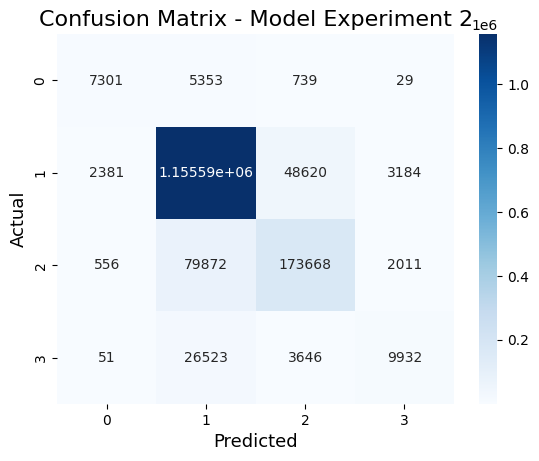

In [67]:
# Getting models prediction
y_prob = model_building.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

#from this get the confusion matrix
model_confuse_mat = confusion_matrix(Y_test, y_pred)
sns.heatmap(model_confuse_mat, annot=True, fmt="g", cmap="Blues")
plt.ylabel("Actual", fontsize=13)
plt.xlabel("Predicted", fontsize=13)
plt.title("Confusion Matrix - Model Experiment 2", fontsize=16)
plt.show()

In [68]:
# Also obtain the classification report
print("Model Experiment 2 (Classification report): ")
print(classification_report(Y_test, y_pred))

Model Experiment 2 (Classification report): 
              precision    recall  f1-score   support

           0       0.71      0.54      0.62     13422
           1       0.91      0.96      0.93   1209775
           2       0.77      0.68      0.72    256107
           3       0.66      0.25      0.36     40152

    accuracy                           0.89   1519456
   macro avg       0.76      0.61      0.66   1519456
weighted avg       0.88      0.89      0.88   1519456



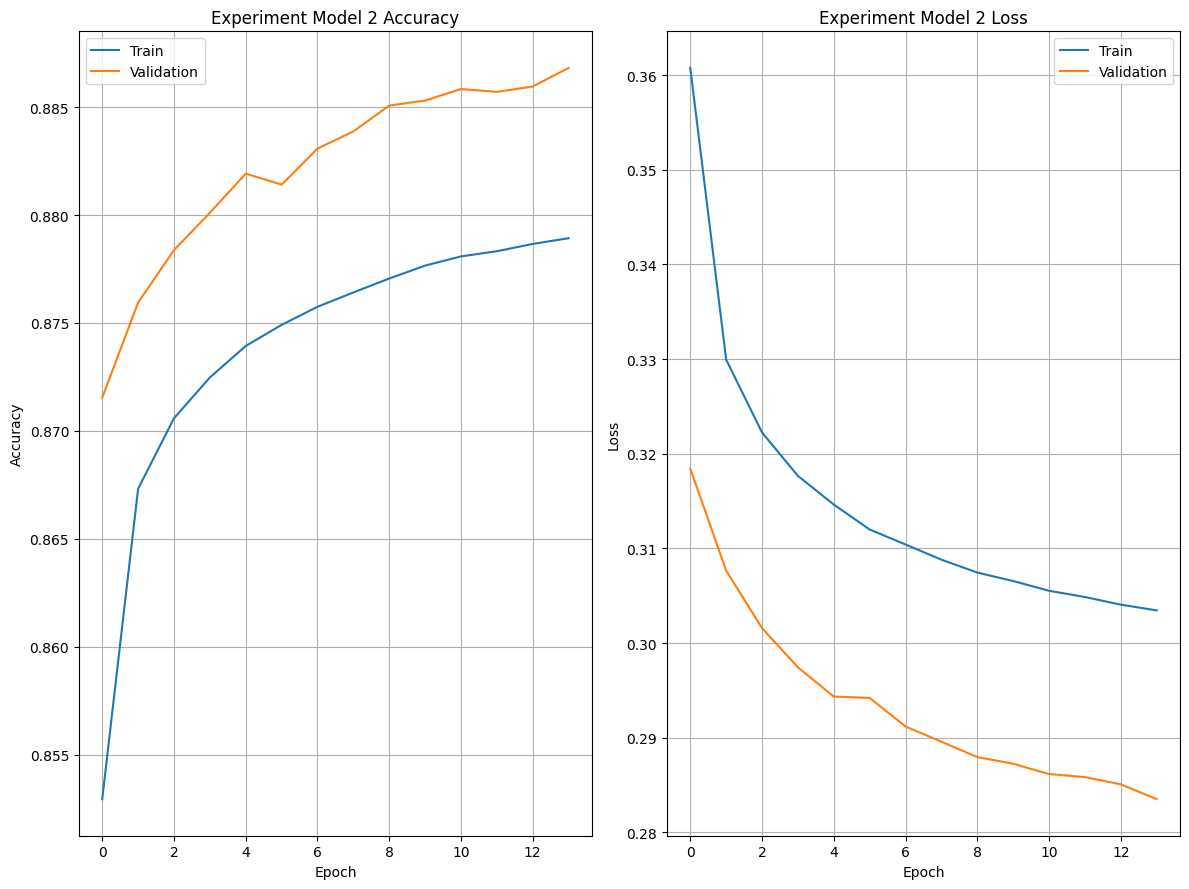

In [69]:
# Plotting the Learning graph of Model 2
fig, (ax1, ax2) = plt.subplots(figsize=(12, 9), ncols=2, nrows=1)
ax1.plot(model_history.history["accuracy"], label="Train")
ax1.plot(model_history.history["val_accuracy"], label="Validation")
ax1.set_title("Experiment Model 2 Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid()

ax2.plot(model_history.history["loss"], label="Train")
ax2.plot(model_history.history["val_loss"], label="Validation")
ax2.set_title("Experiment Model 2 Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()


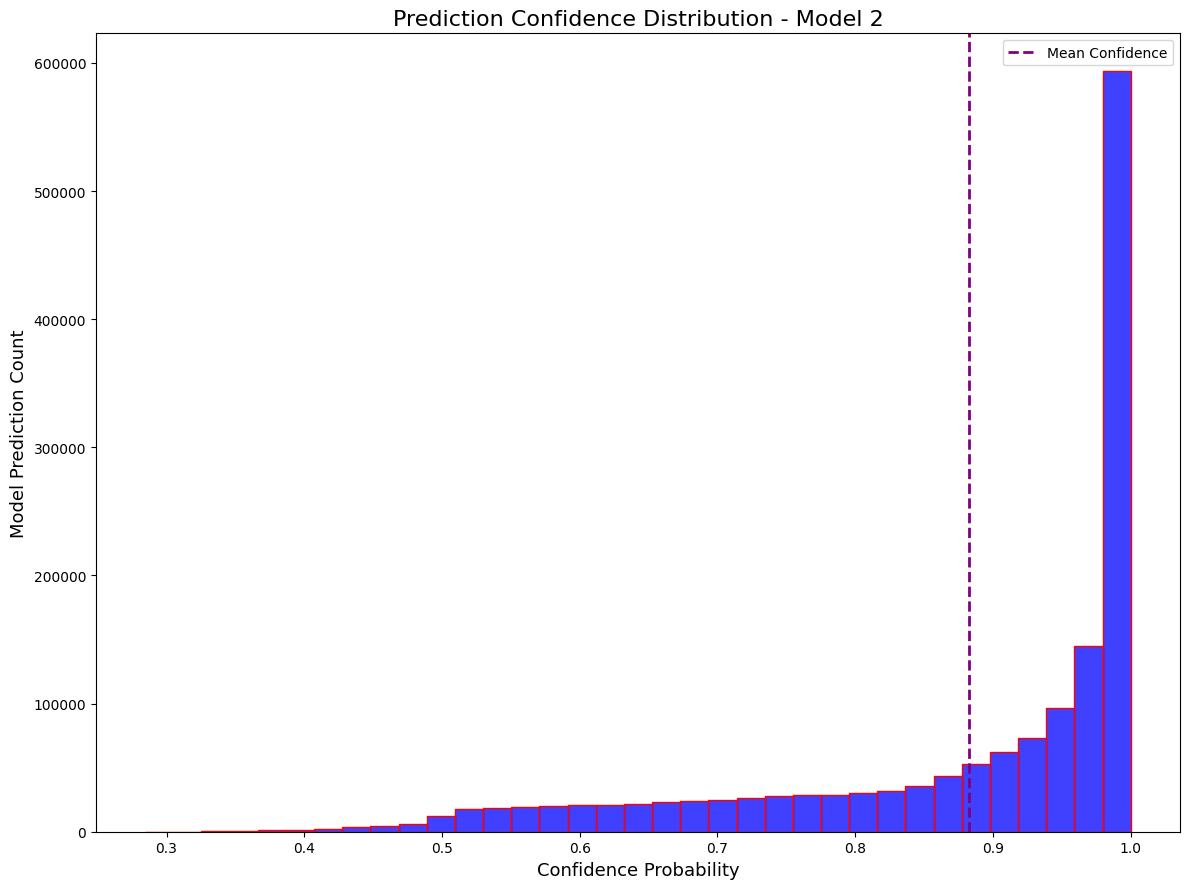

In [70]:
# Obtain models prediction confidence - Model 2
y_pred = np.max(y_prob, axis=1)
convert_to_dataframe = pd.Series(y_pred)

# Plot the model prediction confidence
plt.figure(figsize=(12, 9))
sns.histplot(data=convert_to_dataframe, color="blue", edgecolor="red", bins=35)
plt.axvline(convert_to_dataframe.mean(), color="purple", linestyle="dashed", linewidth=2, label="Mean Confidence")
plt.title("Prediction Confidence Distribution - Model 2", fontsize=16)
plt.xlabel("Confidence Probability", fontsize=13)
plt.ylabel("Model Prediction Count", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

##### Model 3 - ANN (Experimental)

In [71]:
# Model 3 - ANN (Experiment)
def ann_3_experiment_model(num_classes = 4):
    model = tf.keras.Sequential()
    model.add(keras.Input(shape=(X_train.shape[1],)))
    # Adding hidden layers
    model.add(layers.Dense(512, activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.4))

    model.add(layers.Dense(256, activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.3))

    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.2))

    model.add(layers.Dense(64, activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.1))

    model.add(layers.Dense(32, activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.1))


    model.add(layers.Dense(num_classes, activation="softmax"))
    # Compiling the model
    model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model
# To train the model
model_building = ann_3_experiment_model()
model_history = model_building.fit(X_train, Y_train, validation_split=0.2, epochs=20, batch_size=256, callbacks=[tf.keras.callbacks.ReduceLROnPlateau()])

Epoch 1/20
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 84s 4ms/step - accuracy: 0.8483 - loss: 0.3721 - val_accuracy: 0.8697 - val_loss: 0.3213 - learning_rate: 0.0010
Epoch 2/20
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 56s 3ms/step - accuracy: 0.8657 - loss: 0.3329 - val_accuracy: 0.8749 - val_loss: 0.3094 - learning_rate: 0.0010
Epoch 3/20
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 55s 3ms/step - accuracy: 0.8690 - loss: 0.3249 - val_accuracy: 0.8776 - val_loss: 0.3034 - learning_rate: 0.0010
Epoch 4/20
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 55s 3ms/step - accuracy: 0.8709 - loss: 0.3203 - val_accuracy: 0.8790 - val_loss: 0.2998 - learning_rate: 0.0010
Epoch 5/20
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 55s 3ms/step - accuracy: 0.8722 - loss: 0.3176 - val_accuracy: 0.8798 - val_loss: 0.2990 - learning_rate: 0.0010
Epoch 6/20
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 55s 3ms/step - accuracy: 0.8731 - loss: 0.3153 - val_accuracy: 0.8807 - val_loss: 0.2959 - learning_rate: 0.0010
Epoch 7/20
18994/18994 ━━━━━━━━━━━━━━━━━━━━ 55s 3ms/step -

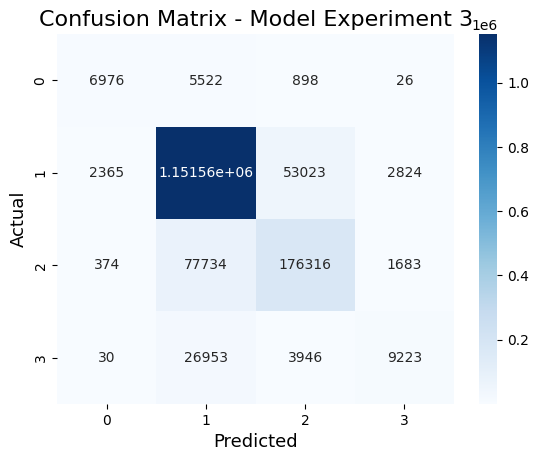

In [72]:
# Getting models prediction
y_prob = model_building.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

#from this get the confusion matrix
model_confuse_mat = confusion_matrix(Y_test, y_pred)
sns.heatmap(model_confuse_mat, annot=True, fmt="g", cmap="Blues")
plt.ylabel("Actual", fontsize=13)
plt.xlabel("Predicted", fontsize=13)
plt.title("Confusion Matrix - Model Experiment 3", fontsize=16)
plt.show()

In [73]:
# Also obtain the classification report
print("Model Experiment 3 (Classification report): ")
print(classification_report(Y_test, y_pred))

Model Experiment 3 (Classification report): 
              precision    recall  f1-score   support

           0       0.72      0.52      0.60     13422
           1       0.91      0.95      0.93   1209775
           2       0.75      0.69      0.72    256107
           3       0.67      0.23      0.34     40152

    accuracy                           0.88   1519456
   macro avg       0.76      0.60      0.65   1519456
weighted avg       0.88      0.88      0.88   1519456



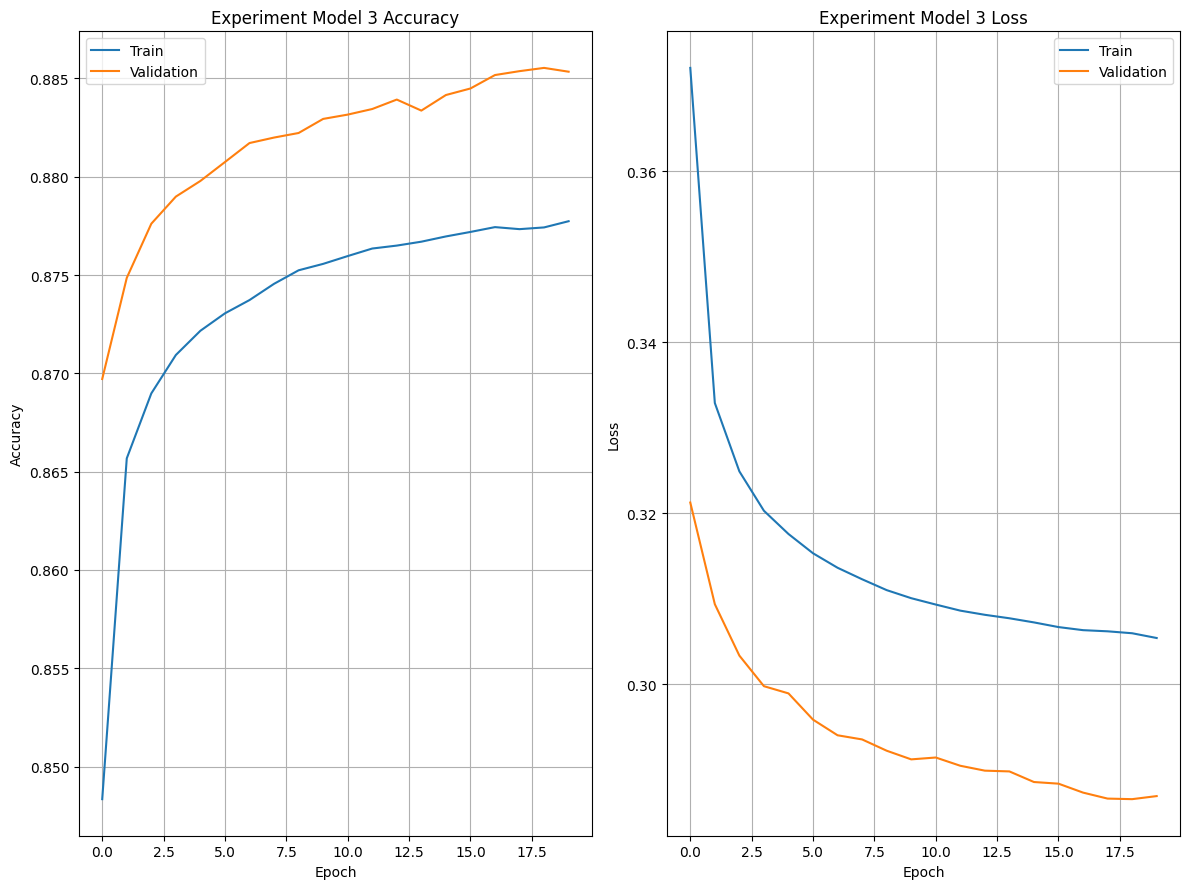

In [74]:
# Plotting the Learning graph of Model 3
fig, (ax1, ax2) = plt.subplots(figsize=(12, 9), ncols=2, nrows=1)
ax1.plot(model_history.history["accuracy"], label="Train")
ax1.plot(model_history.history["val_accuracy"], label="Validation")
ax1.set_title("Experiment Model 3 Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid()

ax2.plot(model_history.history["loss"], label="Train")
ax2.plot(model_history.history["val_loss"], label="Validation")
ax2.set_title("Experiment Model 3 Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

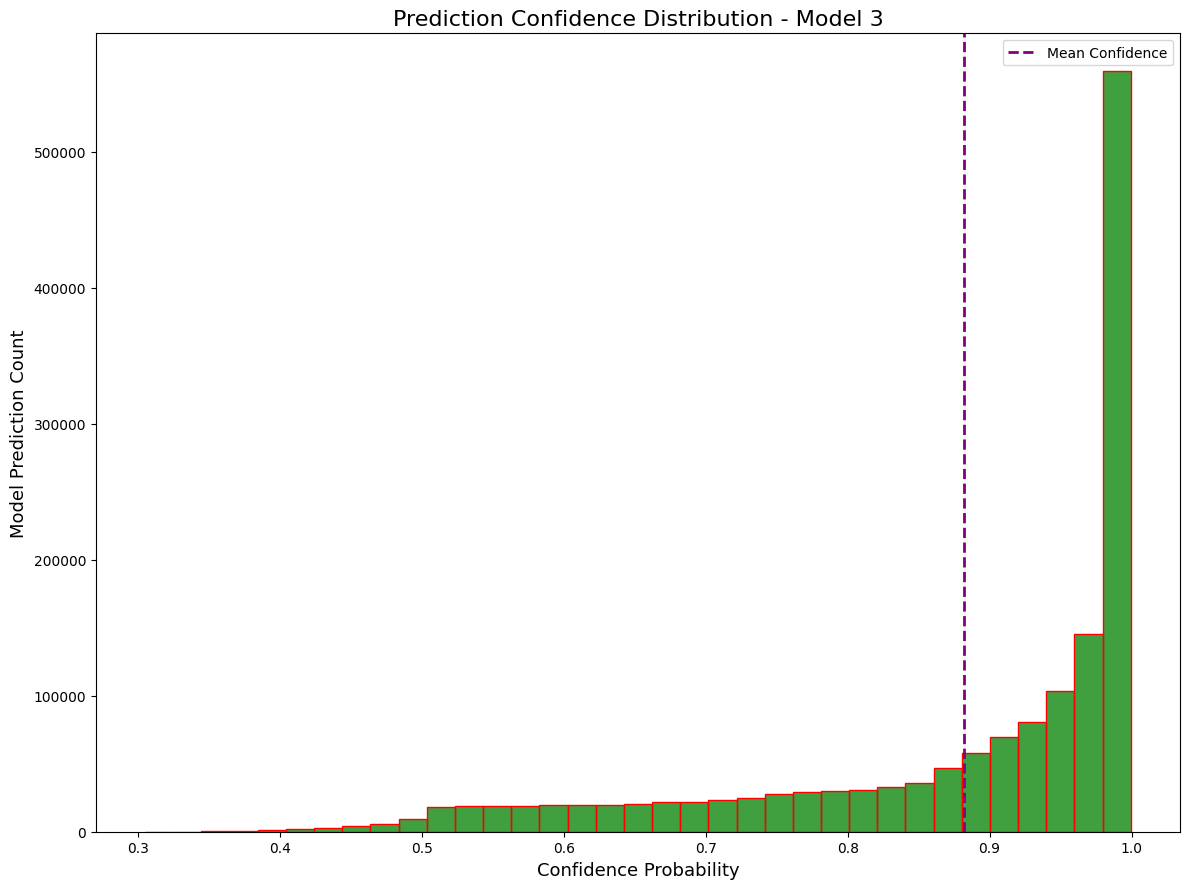

In [75]:
# Obtain models prediction confidence - Model 3
y_pred = np.max(y_prob, axis=1)
convert_to_dataframe = pd.Series(y_pred)

# Plot the model prediction confidence
plt.figure(figsize=(12, 9))
sns.histplot(data=convert_to_dataframe, color="green", edgecolor="red", bins=35)
plt.axvline(convert_to_dataframe.mean(), color="purple", linestyle="dashed", linewidth=2, label="Mean Confidence")
plt.title("Prediction Confidence Distribution - Model 3", fontsize=16)
plt.xlabel("Confidence Probability", fontsize=13)
plt.ylabel("Model Prediction Count", fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

#### Result Comparison

In [77]:
# Gathering all the necessary results and consolidating them into a table
compiled_total_results = {
    "Models": [
        "Model 1", "", "", "", "",
        "Model 2", "", "", "", "",
        "Model 3", "", "", "", ""
    ],

    "Metric Type": [
        "Severity Lvl 1", "Severity Lvl 2", "Severity Lvl 3", "Severity Lvl 4", "Weighted Avg",
        "Severity Lvl 1", "Severity Lvl 2", "Severity Lvl 3", "Severity Lvl 4", "Weighted Avg",
        "Severity Lvl 1", "Severity Lvl 2", "Severity Lvl 3", "Severity Lvl 4", "Weighted Avg"
    ],

    "Precision": [
        0.73, 0.92, 0.77, 0.67, 0.88,
        0.71, 0.91, 0.77, 0.66, 0.88,
        0.72, 0.91, 0.75, 0.67, 0.88
    ],

    "Recall": [
        0.53, 0.95, 0.71, 0.23, 0.89,
        0.54, 0.96, 0.68, 0.25, 0.89,
        0.52, 0.95, 0.69, 0.23, 0.88
    ],

    "F1-Score": [
        0.61, 0.94, 0.74, 0.35, 0.88,
        0.62, 0.93, 0.72, 0.36, 0.88,
        0.60, 0.93, 0.72, 0.34, 0.88
    ],

    "Accuracy": [
        None, None, None, None, 0.89,
        None, None, None, None, 0.89,
        None, None, None, None, 0.88
    ]
}

# Displaying the results
US_acc_severe_total_results = pd.DataFrame(compiled_total_results)
display(US_acc_severe_total_results)

,Models,Metric Type,Precision,Recall,F1-Score,Accuracy
0,Model 1,Severity Lvl 1,0.73,0.53,0.61,NaN
1,,Severity Lvl 2,0.92,0.95,0.94,NaN
2,,Severity Lvl 3,0.77,0.71,0.74,NaN
3,,Severity Lvl 4,0.67,0.23,0.35,NaN
4,,Weighted Avg,0.88,0.89,0.88,0.89
5,Model 2,Severity Lvl 1,0.71,0.54,0.62,NaN
6,,Severity Lvl 2,0.91,0.96,0.93,NaN
7,,Severity Lvl 3,0.77,0.68,0.72,NaN
8,,Severity Lvl 4,0.66,0.25,0.36,NaN
9,,Weighted Avg,0.88,0.89,0.88,0.89
